# Open quantum systems II — quantum trajectories (Monte-Carlo wave function)

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 6 — Open quantum systems*

## 1. Introduction and motivation

The [previous notebook](16_lindblad_master_equation.ipynb) solved the Lindblad master equation

$$ \frac{d\rho}{dt} = -i[H,\rho] + \sum_j\gamma_j\Big(L_j\rho L_j^\dagger - \tfrac12\{L_j^\dagger L_j,\rho\}\Big) \tag{1}$$

by evolving the density tensor $\rho$ with its $4^N$ entries. That works comfortably up to $N\approx8$ spins and hits a
wall at $N\approx13$, where a single copy of $\rho$ fills a gigabyte. A state vector of the same 13 spins takes 131 kB.
Could we simulate an *open* system at the price of a *closed* one?

We can, by changing the question. Eq. (1) describes an **ensemble**: what we know on average about infinitely many
copies of the experiment. But think of *one* copy — a single trapped ion, say, driven by a laser and watched by a
photodetector. Its record is a sequence of clicks at random times. Between clicks the ion has a wave function that evolves
smoothly; at a click the wave function changes abruptly — a **quantum jump**. Such jumps are not a figure of speech:
they were observed directly in 1986 as the random switching on and off of the fluorescence of single trapped ions,
and in 2019 a superconducting-qubit experiment even caught a jump "mid-flight".

The **Monte-Carlo wave function (MCWF)** method — also called the *quantum-jump* or *quantum-trajectory* method,
developed around 1992 by Dalibard, Castin and Mølmer, by Dum, Zoller and Ritsch, and by Carmichael — turns this picture into an algorithm:

1. simulate a **pure state** $|\psi(t)\rangle$ that evolves smoothly under a non-Hermitian *effective Hamiltonian* and, at
   random times, jumps: $|\psi\rangle\to L_j|\psi\rangle$;
2. repeat $M$ times with different random numbers;
3. average: $\overline{|\psi\rangle\langle\psi|}\to\rho(t)$, the solution of Eq. (1), with a statistical error $\propto1/\sqrt M$.

Memory drops from $4^N$ to $2^N$ numbers; the price is the sampling noise, and $M$ independent runs — which are
*embarrassingly parallel* and therefore a perfect match for `jax.vmap`.

**Road map.**

* Section 2 derives the method carefully: the effective Hamiltonian, the jump probabilities, the proof that the average over
  trajectories obeys Eq. (1), and the relation to the Kraus channels of notebook 07 (Chapter 3) and to the Trotter–Kraus step of the previous
  notebook; it closes with the rule for choosing $dt$ and with the waiting-time formulation of the algorithm.
* Section 3 implements one MCWF step and tests it on a single qubit, where everything is known analytically — including
  the surprising role of *not* detecting a photon.
* Section 4 builds the many-body machinery, `lax.scan` over time and `jax.vmap` over trajectories, for two different steppers.
* Section 5 is the central numerical experiment, the **$2\times2$ comparison**: {density matrix, trajectories} $\times$ {RK4, Trotter} for a dephasing XXZ chain.
* Section 6 studies the statistical error: error bars, the $1/\sqrt M$ law, and how to test error bars themselves.
* Section 7 looks at single trajectories of a many-body system — staircases of quantum jumps, click records, and entanglement that the ensemble average hides.
* Section 8 measures the memory/time trade-off against $N$ and finishes with an open chain of $N=16$ spins, where the density tensor
  would need 69 GB, checked against an exact analytic law.

### What you will learn

**Physics**

* quantum jumps and continuous measurement: what a single open quantum system does, as opposed to the ensemble;
* the effective Hamiltonian $H_{\rm eff}=H-\tfrac i2\sum_j\gamma_jL_j^\dagger L_j$ and why "no click" is also information;
* that many different stochastic processes ("unravellings") share the same $\rho(t)$ — and that trajectories can be entangled while $\rho$ is not.

**Numerical methods**

* the first-order MCWF algorithm and its Kraus form; two steppers (RK4 under $H_{\rm eff}$ + collective jump decision; unravelled Trotter–Kraus step);
  the waiting-time algorithm it approximates, and the rule $\sum_j\delta p_j\lesssim0.1$ for the time step;
* systematic ($dt$) versus statistical ($1/\sqrt M$) error; standard error of the mean, pulls, how to validate error bars;
  which quantities a trajectory average estimates without bias (linear in $\rho$) and which it does not;
* cost model $M\cdot2^N$ versus $4^N$ and the break-even number of trajectories.

**Implementation practice**

* explicit PRNG keys: one key per trajectory, split per time step, split again per jump operator — reproducible randomness;
* `lax.scan` (time) inside `jax.vmap` (trajectories) inside `jax.jit`; random branching without Python `if` (`jax.random.categorical` + `lax.switch`);
* timing with compilation separated from execution, batches instead of wasted warm-up runs.

### Prerequisites
* [notebook 16 (Chapter 6) — the Lindblad master equation](16_lindblad_master_equation.ipynb): Eq. (1), jump operators, RK4 and Trotter–Kraus steps on the density tensor;
* [notebook 07 (Chapter 3) — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): Kraus channels and their stochastic unravelling `apply_kraus_mcwf`;
* [notebook 12 (Chapter 5) — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): `tebd_gates`;
* [notebook 01 (Chapter 1) — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys.

Units and conventions as before: $\hbar=1$; $|0\rangle$ is the $+1$ eigenstate of $Z$; $\sigma^\pm=(X\pm iY)/2$, so that
$\sigma^-=|1\rangle\langle0|$ lowers spin up $|0\rangle$ to spin down $|1\rangle$ and $\sigma^+=|0\rangle\langle1|$ (engine: `SP`)
raises it, taking the excited level $|1\rangle$ to $|0\rangle$: decay has the jump operator $\sigma^+$ (quantum-optics texts call it
$\sigma^-$, see [notebook 16](16_lindblad_master_equation.ipynb)).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
SP = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^+ = |0><1| = (X + iY)/2 : spin raising |1> -> |0>, the decay jump operator
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_from_jump(L, gamma_dt):
    """Kraus pair generated by a Lindblad jump operator L acting for a short time dt (rate gamma):
        K1 = sqrt(gamma dt) L                      'a jump happened'
        K0 = sqrt(1 - gamma dt L^dag L)            'no jump'  (~ exp(-gamma dt L^dag L / 2))
    Completeness K0^dag K0 + K1^dag K1 = 1 holds EXACTLY whenever gamma dt ||L^dag L|| <= 1, so that
    1 - gamma dt L^dag L is positive semidefinite and its square root exists; the map is then trace preserving.
    For larger steps the negative eigenvalues are clipped by _sqrtm_psd and completeness FAILS (decay L = |0><1| = SP,
    gamma dt = 1.5: error 0.5).  It reproduces the Lindblad dissipator up to O(dt^2)."""
    L = jnp.asarray(L, dtype=CDTYPE)
    K0 = _sqrtm_psd(jnp.eye(L.shape[0], dtype=CDTYPE) - gamma_dt * (L.conj().T @ L))
    return jnp.stack([K0, jnp.sqrt(gamma_dt) * L])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho


# ----------------------------------------------------------------------------
# 10. Open systems: Lindblad master equation (density tensor) and quantum trajectories (MCWF)
# ----------------------------------------------------------------------------
def lindblad_rhs(rho, terms, jumps):
    """Right-hand side of the Lindblad (GKSL) master equation, matrix-free:
        d rho/dt = -i[H, rho] + sum_j gamma_j ( L_j rho L_j^dag - (1/2){L_j^dag L_j, rho} ).
    `jumps` = [(qubits, L, gamma), ...].

    KEY TRICK   left multiplication  O rho  acts on KET axes with O;
                right multiplication rho O  acts on BRA axes with O^T     [ (rho O)_{ab} = sum_c rho_{ac} O_{cb} ].
                So every term is again `apply_gate` on a rank-2N tensor.
    """
    N = rho.ndim // 2
    out = jnp.zeros_like(rho)
    for q, h in terms:
        bq = [N + x for x in q]
        out = out - 1j * (apply_gate(rho, h, q) - apply_gate(rho, jnp.asarray(h).T, bq))
    for q, L, g in jumps:
        L = jnp.asarray(L, dtype=CDTYPE)
        bq = [N + x for x in q]
        LdL = L.conj().T @ L
        out = out + g * (apply_gate(apply_gate(rho, L, q), jnp.conj(L), bq)
                         - 0.5 * apply_gate(rho, LdL, q) - 0.5 * apply_gate(rho, LdL.T, bq))
    return out

def lindblad_rk4_step(rho, terms, jumps, dt):
    """Classical 4th-order Runge-Kutta step for d rho/dt = L(rho): local error O(dt^5).
    TRACE   conserved to round-off: every term of the Lindblad generator is traceless and the step is a linear
            combination of generator evaluations.  This holds even beyond the stability limit, so a correct trace
            does NOT certify a healthy run.
    POSITIVITY   not guaranteed: small negative eigenvalues appear for moderate dt, and the run blows up once
            dt * ||L|| exceeds the RK4 stability bound."""
    f = lambda r: lindblad_rhs(r, terms, jumps)
    k1 = f(rho)
    k2 = f(rho + 0.5 * dt * k1)
    k3 = f(rho + 0.5 * dt * k2)
    k4 = f(rho + dt * k3)
    return rho + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def lindblad_trotter_step_dm(rho, gates, jump_kraus):
    """Trotterised Lindblad step on a density tensor: unitary TEBD gates, then one Kraus channel per
    jump operator (`jump_kraus` = [(qubits, kraus_from_jump(L, gamma*dt)), ...]).
    Completely positive and trace preserving by construction, first order in the dissipator."""
    rho = apply_gates_dm(rho, gates)
    for q, K in jump_kraus:
        rho = apply_kraus_dm(rho, K, q)
    return rho

def lindblad_trotter_step_mcwf(key, psi, gates, jump_kraus):
    """The SAME step unravelled on a pure state (Monte-Carlo wave function): each Kraus channel is
    sampled with `apply_kraus_mcwf`.  The trajectory average equals `lindblad_trotter_step_dm` exactly,
    so DM-vs-MCWF comparisons test only the statistical error ~ 1/sqrt(n_traj).
    JAX: scan over time steps, vmap over trajectory keys."""
    psi = apply_gates(psi, gates)
    keys = jax.random.split(key, max(len(jump_kraus), 1))
    for k, (q, K) in zip(keys, jump_kraus):
        psi = apply_kraus_mcwf(k, psi, K, q)
    return psi


## 2. Theory: unravelling the master equation

### 2.1 The master equation in "effective Hamiltonian" form

Collect in Eq. (1) everything that multiplies $\rho$ from the left, and everything that multiplies it from the right:

$$ \frac{d\rho}{dt} = -i\big(H_{\rm eff}\,\rho-\rho\,H_{\rm eff}^\dagger\big) + \sum_j\gamma_jL_j\rho L_j^\dagger,
   \qquad\boxed{H_{\rm eff} = H-\frac i2\sum_j\gamma_jL_j^\dagger L_j} \tag{2}$$

(check: $-iH_{\rm eff}\rho = -iH\rho-\tfrac12\sum_j\gamma_jL_j^\dagger L_j\rho$, and $+i\rho H_{\rm eff}^\dagger = +i\rho H-\tfrac12\sum_j\gamma_j\rho L_j^\dagger L_j$.)
The first term looks like a Schrödinger equation with a **non-Hermitian** Hamiltonian; the second, the "jump term",
is the only one that cannot be written as an operation on a ket alone. The MCWF method treats the first
deterministically and the second stochastically.

### 2.2 The stochastic process

Let $|\psi(t)\rangle$ be normalised and $dt$ small. One step of the (first-order) algorithm:

**(a) Jump probabilities.** For every jump operator compute

$$ \delta p_j = \gamma_j\,dt\,\langle\psi|L_j^\dagger L_j|\psi\rangle = \gamma_j\,dt\,\|L_j|\psi\rangle\|^2,\qquad \delta p=\sum_j\delta p_j\ll1 . $$

**(b) With probability $1-\delta p$: no jump.** Evolve with the effective Hamiltonian and renormalise,

$$ |\tilde\psi\rangle = (\mathbb 1-iH_{\rm eff}\,dt)|\psi\rangle,\qquad |\psi(t+dt)\rangle = \frac{|\tilde\psi\rangle}{\||\tilde\psi\rangle\|} . $$

Because $H_{\rm eff}$ is not Hermitian the norm *shrinks*, and by exactly the right amount:

$$ \langle\tilde\psi|\tilde\psi\rangle = \langle\psi|(\mathbb 1+iH_{\rm eff}^\dagger dt)(\mathbb 1-iH_{\rm eff}dt)|\psi\rangle
   = 1+i\,dt\,\langle\psi|H_{\rm eff}^\dagger-H_{\rm eff}|\psi\rangle+O(dt^2) = 1-dt\sum_j\gamma_j\langle L_j^\dagger L_j\rangle = 1-\delta p . \tag{3}$$

*The loss of norm under $H_{\rm eff}$ is the probability that a jump has happened.*

**(c) With probability $\delta p_j$: jump number $j$.**

$$ |\psi(t+dt)\rangle = \frac{L_j|\psi\rangle}{\|L_j|\psi\rangle\|} = \frac{L_j|\psi\rangle}{\sqrt{\delta p_j/(\gamma_j\,dt)}} . $$

Physically, $j$ labels a detector channel (a photon from atom $j$, a phase kick on spin $j$, ...). The rule says: clicks in channel
$j$ arrive with rate $\gamma_j\langle L_j^\dagger L_j\rangle$, and a click updates the state by $L_j$.

### 2.3 Proof: the average over trajectories obeys the Lindblad equation

Let $\sigma(t)=|\psi(t)\rangle\langle\psi(t)|$ and average $\sigma(t+dt)$ over the random outcome of **one** step, weighting the
branches (b) and (c) with their probabilities:

$$ \overline{\sigma(t+dt)} = (1-\delta p)\,\frac{|\tilde\psi\rangle\langle\tilde\psi|}{1-\delta p} +
\sum_j\delta p_j\,\frac{L_j|\psi\rangle\langle\psi|L_j^\dagger}{\delta p_j/(\gamma_j dt)} . $$

The **probabilities cancel against the normalisation factors** — this is the heart of the method. What remains is *linear* in $\sigma$:

$$ \overline{\sigma(t+dt)} = (\mathbb 1-iH_{\rm eff}dt)\,\sigma\,(\mathbb 1+iH_{\rm eff}^\dagger dt)+dt\sum_j\gamma_jL_j\sigma L_j^\dagger
   = \sigma+dt\Big[-i\big(H_{\rm eff}\sigma-\sigma H_{\rm eff}^\dagger\big)+\sum_j\gamma_jL_j\sigma L_j^\dagger\Big]+O(dt^2). $$

The bracket is the right-hand side of Eq. (2), $\mathcal L(\sigma)$. Finally average over the state at time $t$ as well (over all
earlier random choices): since the bracket is linear, $\overline{\mathcal L(\sigma)} = \mathcal L(\overline\sigma)$, and with
$\rho(t):=\overline{\sigma(t)}$

$$ \rho(t+dt) = \rho(t)+dt\,\mathcal L\big(\rho(t)\big)+O(dt^2)\qquad\Longrightarrow\qquad \dot\rho=\mathcal L(\rho)\quad(dt\to0). \qquad\blacksquare$$

Every single trajectory is a **nonlinear** stochastic process (renormalisation, state-dependent probabilities), yet the
ensemble average is the **linear** master equation. For any observable,
$\mathrm{Tr}(\rho\,O) = \overline{\langle\psi|O|\psi\rangle}$: we average ordinary pure-state expectation values.

### 2.4 Kraus operators of a single step

Define the operators

$$ K_0 = \mathbb 1-iH_{\rm eff}\,dt,\qquad K_j=\sqrt{\gamma_j\,dt}\;L_j\quad(j\ge1). $$

Then $\delta p_j = \|K_j\psi\|^2$, $1-\delta p = \|K_0\psi\|^2$, the step reads "choose branch $m$ with probability $\|K_m\psi\|^2$, replace
$|\psi\rangle\to K_m|\psi\rangle/\|K_m\psi\|$", and its average is the channel $\rho\mapsto\sum_mK_m\rho K_m^\dagger$. Both statements hold only
to $O(dt^2)$: $\sum_mK_m^\dagger K_m = \mathbb 1+dt^2H_{\rm eff}^\dagger H_{\rm eff}$, so the branch probabilities do not add up to exactly one and the
channel is not exactly trace preserving. (`kraus_from_jump` repairs this, see below.) This is *exactly* the
stochastic unravelling of a Kraus channel from [notebook 07 (Chapter 3), Section 11](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)
(engine: `apply_kraus_mcwf`), applied to the short-time channel from which we *derived* the Lindblad equation in the
[previous notebook, Section 2.3](16_lindblad_master_equation.ipynb). Nothing new had to be invented.

This observation gives us a second algorithm for free. The **Trotter–Kraus step** of the previous notebook factorises the
short-time channel into a product of simple CPTP maps,

$$ \rho(t+dt)\approx\mathcal E_{J}\circ\dots\circ\mathcal E_{1}\circ\mathcal U\,(\rho),\qquad \mathcal U(\rho)=U\rho U^\dagger,\quad
   \mathcal E_j(\rho)=K^{(j)}_0\rho K^{(j)\dagger}_0+K^{(j)}_1\rho K^{(j)\dagger}_1, $$

with TEBD gates for $U\approx e^{-iHdt}$ and `kraus_from_jump`: $K_1^{(j)}=\sqrt{\gamma_jdt}L_j$, $K_0^{(j)}=\sqrt{\mathbb 1-\gamma_jdt\,L_j^\dagger L_j}$.
Expanding the product, $\mathcal E_J\circ\dots\circ\mathcal U = \mathbb 1+dt\,\mathcal L+O(dt^2)$: the same master equation to first order.
Unravel *each factor* on a pure state — apply the gates, then sample every two-outcome channel in turn — and you obtain
the engine's `lindblad_trotter_step_mcwf`. Its trajectory average equals `lindblad_trotter_step_dm` **exactly**, for any $dt$,
which makes this pair a clean test of the *statistics* alone.

| | stepper A: "MCWF + RK4" (Section 3) | stepper B: "MCWF + Trotter" (engine) |
|---|---|---|
| coherent + no-jump part | RK4 integration of $\partial_t\lvert\psi\rangle=-iH_{\rm eff}\lvert\psi\rangle$ | TEBD gates, then $K_0^{(j)}$ per site |
| jump decision | one collective decision per step (at most one jump) | one independent two-outcome decision per jump operator |
| average map | Eq. (1) up to $O(dt)$ | `lindblad_trotter_step_dm` exactly; Eq. (1) up to $O(dt)$ |
| returns which jump happened | yes | no |

### 2.5 The meaning of a single trajectory

* **Continuous measurement.** If every quantum emitted into the environment is detected, the record of clicks is one realisation
  of the process of Section 2.2 and $|\psi(t)\rangle$ is the experimenter's best knowledge *conditioned* on that record.
  Branch (b) is then a genuine measurement result too: "no click during $dt$". It changes the state (Section 3.3).
* **The trajectory is tied to one measurement scheme.** The process of Section 2.2 is the record of an *ideal photon counter*:
  a click means "one quantum went into the environment through channel $j$", and the state collapses by $L_j$. Read that way,
  $\gamma_j\langle L_j^\dagger L_j\rangle$ is a photon count rate and the jumps are detector events, not a numerical device.
* **Not unique.** Measuring the environment differently gives a *different* stochastic process with the same average.
  Formally, Kraus operators are defined only up to a unitary mixing, $K_m\to\sum_nu_{mn}K_n$, and every choice of $u$ is a
  legitimate measurement of the environment. Mixing the no-jump operator $K_0$ into the jump operators with a large amplitude
  (physically: interfering the emitted light with a strong local oscillator before the detector — *homodyne detection*) turns the
  rare large jumps into a continuous small-noise diffusion — a **diffusive** unravelling, of which the quantum-state-diffusion
  equation of Gisin and Percival is the best-known example.
  Anything *linear* in $|\psi\rangle\langle\psi|$ (expectation values, and fidelities with a fixed pure state) is
  unravelling-independent, because it is a property of $\rho$ alone; nonlinear functionals of the state averaged over trajectories
  (the entanglement entropy of $|\psi\rangle$, the purity of a subsystem) are **not** properties of $\rho$ and change when the detection
  scheme changes. We shall see an example in Section 7.

### 2.6 Statistical error

With $M$ independent trajectories the estimator of $\langle O\rangle(t)=\mathrm{Tr}(\rho(t)O)$ and its standard error are

$$ \bar O = \frac1M\sum_{i=1}^M o_i,\quad o_i=\langle\psi_i|O|\psi_i\rangle;\qquad
   \mathrm{SE} = \frac{s}{\sqrt M},\quad s^2=\frac1{M-1}\sum_i(o_i-\bar O)^2 . \tag{4}$$

By the central limit theorem $\bar O$ is Gaussian around the mean of the estimator with standard deviation $\mathrm{SE}$: that mean lies
within $\pm1\,\mathrm{SE}$ in 68 % and within $\pm2\,\mathrm{SE}$ in 95 % of cases. Halving the error costs four times more trajectories.

Two caveats that decide how the method is used in practice.

**(i) Which quantities are estimated without bias.** $\bar O$ is unbiased for the *finite-$dt$* value of any quantity **linear** in $\rho$:
expectation values $\mathrm{Tr}(\rho O)$, and fidelities $\langle\chi|\rho|\chi\rangle$ with a fixed **pure** target. (The remaining offset from the
exact Lindblad solution is the systematic $dt$ error of Section 2.7, not a statistical one.) Quantities that are **nonlinear** in $\rho$ —
purity $\mathrm{Tr}\rho^2$, von Neumann or entanglement entropy of $\rho$, variances $\langle O^2\rangle-\langle O\rangle^2$ assembled from estimated means,
fidelity with a *mixed* target — cannot be obtained by inserting $\bar O$ into the formula: the plug-in estimator carries a bias of order
$1/M$ on top of its statistical error. Worse, averaging the nonlinear quantity over trajectories does not help either, because
$\overline{f(|\psi_i\rangle\langle\psi_i|)}\ne f(\rho)$ for nonlinear $f$; that average is a property of the *unravelling* (Section 2.5), which is
exactly the point of Section 7. Everything this notebook averages over trajectories is linear, except the entanglement entropy of
Section 7, which is discussed there as a quantity in its own right.

**(ii) How $s$ scales with $N$.** For a bounded observable, $|o_i|\le1$ gives $s\le1$ **independently of $N$** — this holds for single Pauli
operators and for the site-*averaged* quantities used below, so the number of trajectories needed for a fixed *absolute* accuracy of an
intensive observable does not grow with the Hilbert-space dimension. It does **not** hold for **extensive** observables. The total excitation
number $\hat n=\sum_i|1\rangle\langle1|_i$ of Sections 7 and 8.3 ranges over $0\ldots N$, and for weakly correlated sites its trajectory-to-trajectory
standard deviation grows as $s\sim\sqrt{N}$ (a sum of $N$ nearly independent contributions). Fixed *absolute* accuracy on $\hat n$ therefore costs
$M\propto N$ trajectories; fixed *relative* accuracy is cheaper still: $\langle\hat n\rangle$ itself grows like $N$, so the relative error is of order
$1/\sqrt{NM}$ and the required $M$ falls like $1/N$.

### 2.7 Step size and the waiting-time algorithm

The scheme of Section 2.2 makes **one Bernoulli decision per step** and allows **at most one jump per step**. Both approximations are
controlled by the same small parameter, the expected number of clicks in one step:

$$ \delta p = dt\sum_j\gamma_j\langle L_j^\dagger L_j\rangle . $$

Two jumps inside one step are missed with probability $\tfrac12(\delta p)^2$ per step, i.e. $\tfrac12\delta p\cdot(\delta p/dt)$ per unit time, and the
jump is applied at the end of the step rather than at a uniformly distributed instant inside it, an error of order $dt$ in the jump time.
Both are $O(dt)$ errors in the trajectory average, with a prefactor set by the total rate $\Gamma=\sum_j\gamma_j\langle L_j^\dagger L_j\rangle$:
the relative bias of a quantity decaying at rate $\Gamma$ accumulates as $\sim\tfrac12\Gamma^2\,dt\,t$. (The Trotter–Kraus stepper of Section 2.4
has a bias of exactly this form: it multiplies an excited population by $1-\gamma dt$ per step instead of $e^{-\gamma dt}$, so the population
decays as $(1-\gamma dt)^{t/dt}=e^{-\gamma t}\,e^{-\gamma^2dt\,t/2}$. Section 8.3 measures it.)

> **Numerical practice.** Choose $dt$ so that $\delta p=dt\sum_j\gamma_j\langle L_j^\dagger L_j\rangle\lesssim0.1$, and separately so that the
> coherent step is accurate ($dt\,\lVert H\rVert\ll1$). The first condition is **extensive**: with one jump operator per site the sum has $N$
> terms, so at fixed $\gamma$ the admissible $dt$ shrinks like $1/N$. The engine's Trotter stepper escapes this restriction — it takes an
> *independent* two-outcome decision per jump operator, so several sites may click in the same step; its only hard constraint is
> $\gamma_jdt\le1$, so that $K_0=\sqrt{\mathbb 1-\gamma_jdt\,L_j^\dagger L_j}$ exists. That is why Section 8.3 can run $N=16$ sites at
> $\delta p\approx0.16$ with the Trotter stepper, a value that would be too large for stepper A.

**The waiting-time (delay-function) algorithm.** The scheme of Section 2.2 is the one of Dalibard, Castin and Mølmer; the scheme of
Dum, Zoller and Ritsch, who draw each decay time from the photon-count distribution of the driven atom, avoids the per-step Bernoulli
draw altogether. Draw a single uniform random number $r\in(0,1)$, propagate the **unnormalised** state under $H_{\rm eff}$ without
renormalising, and wait until its squared norm has fallen to $r$:

$$ \langle\tilde\psi(t_{\rm jump})|\tilde\psi(t_{\rm jump})\rangle = r . $$

Because the squared norm *is* the no-jump probability (Eq. (3)), $t_{\rm jump}$ drawn this way has exactly the right distribution — for any
step size, since the norm is obtained from a deterministic integration that can be made as accurate as one likes. At $t_{\rm jump}$ pick the
channel with probability $\propto\gamma_j\|L_j\tilde\psi\|^2$, apply $L_j$, renormalise, draw a new $r$ and continue. The scheme of
Section 2.2 is the first-order, fixed-grid approximation to this: it replaces the exact waiting time by one Bernoulli trial per step.
The waiting-time version costs a root search inside the time loop (and, on a fixed grid, an interpolation of the crossing — without it the
jump time is again quantised in units of $dt$ and the $O(dt)$ bias returns), which is awkward under `lax.scan`. This notebook therefore uses
the fixed-grid schemes and keeps $dt$ small; Exercise 7 builds the waiting-time version.

## 3. One MCWF step for a single qubit

### 3.1 From formula to code

We implement stepper A for an arbitrary number of spins, matrix-free, with the conventions of the engine:
`terms = [(qubits, h), ...]` for $H$ and `jumps = [(qubits, L, gamma), ...]` for the dissipation.

* **`apply_neg_i_heff`** — the right-hand side $-iH_{\rm eff}|\psi\rangle = -i\sum_kh_k|\psi\rangle-\tfrac12\sum_j\gamma_jL_j^\dagger L_j|\psi\rangle$. Every term is a
  small matrix acting on one or two tensor axes: `apply_gate` (which does not require unitarity).
* **No-jump propagation.** The Euler step $(\mathbb 1-iH_{\rm eff}dt)$ of Section 2.2 is fine for a proof but poor numerics: we saw in
  the previous notebook that Euler is unstable for oscillatory dynamics. We integrate $\partial_t|\psi\rangle=-iH_{\rm eff}|\psi\rangle$ over $dt$ with one
  **RK4** step instead; the norm then decays like $e^{-\delta p}$ to high accuracy.
* **Jump decision from the norm.** Following Eq. (3) we take the no-jump probability from the propagated state itself,
  $p_0=\langle\tilde\psi|\tilde\psi\rangle$, and distribute the remaining $1-p_0$ over the channels in proportion to the rates
  $w_j=\gamma_j\|L_j\tilde\psi\|^2$. If a jump occurs it is applied to the propagated state. Compared with Section 2.2 all
  changes are of relative order $dt$ within a branch of probability $O(dt)$, so the proof goes through unchanged, but the error *constant* is
  smaller (a jump step no longer "loses" its coherent evolution).
* **$\|L_j\tilde\psi\|^2$ without applying $L_j$.** $\langle\tilde\psi|L_j^\dagger L_j|\tilde\psi\rangle=\mathrm{Tr}(\tilde\rho_q\,L_j^\dagger L_j)$ with the
  (unnormalised) single-site reduced density matrix from `rdm`. For $N$ single-site channels that is $N$ cheap contractions.
* **Branching without `if`.** The outcome $m\in\{0,1,\dots,J\}$ is a *traced* random integer, so a Python `if` cannot be
  used under `jit`. `jax.random.categorical(key, log p)` draws $m$; `lax.switch(m, branches, state)` applies the chosen
  branch ($m=0$: nothing, $m=j$: $L_j$). Under `vmap`, `switch` evaluates all branches and selects — $J$ cheap single-site operations.

> **JAX practice.** Random numbers in JAX are *explicit*: a function that needs randomness takes a `key` argument and the
> same key always gives the same numbers. Keys are never reused: `jax.random.split(key, n)` produces `n` independent
> children. Our hierarchy: one key per trajectory → split into one key per time step → (engine stepper) split again per jump operator.

In [3]:
# ==============================================================================
# STEP 1: stepper A -- RK4 under H_eff + one collective jump decision
# ==============================================================================
def apply_neg_i_heff(psi, terms, jumps):
    """Right-hand side of the no-jump evolution:  -i H_eff |psi>,  matrix-free.

    MATH   H_eff = H - (i/2) sum_j gamma_j L_j^dag L_j      (non-Hermitian: the norm of psi decays)
           -i H_eff psi = -i sum_k h_k psi  -  (1/2) sum_j gamma_j (L_j^dag L_j) psi
    COST   O((#terms + #jumps) 2^N), memory O(2^N).
    """
    out = jnp.zeros_like(psi)
    for q, h in terms:
        out = out - 1j * apply_gate(psi, h, q)
    for q, L, g in jumps:
        L = jnp.asarray(L, dtype=CDTYPE)
        out = out - 0.5 * g * apply_gate(psi, L.conj().T @ L, q)
    return out


def nojump_rk4_step(psi, terms, jumps, dt):
    """One RK4 step of d|psi>/dt = -i H_eff |psi>.  The state is NOT renormalised:
    <psi~|psi~> = exp(-dt sum_j gamma_j <L_j^dag L_j>) + O(dt^2) is the no-jump probability, Eq. (3)."""
    f = lambda p: apply_neg_i_heff(p, terms, jumps)
    k1 = f(psi)
    k2 = f(psi + 0.5 * dt * k1)
    k3 = f(psi + 0.5 * dt * k2)
    k4 = f(psi + dt * k3)
    return psi + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def mcwf_rk4_step(key, psi, terms, jumps, dt):
    """One Monte-Carlo wave-function step (first order in the jump statistics).  Returns (psi_new, m).

    MATH   psi~ = no-jump propagation under H_eff ;   p_0 = <psi~|psi~>              (no jump)
           p_j = (1 - p_0) w_j / sum_j w_j ,   w_j = gamma_j ||L_j psi~||^2          (jump in channel j)
           m = 0:  psi -> psi~ / ||psi~||          m = j >= 1:  psi -> L_j psi~ / ||L_j psi~||
    IMPLEMENTATION   w_j from the single-site reduced density matrix (einsum inside `rdm`);
                     the random branch is drawn with `categorical` and applied with `lax.switch` (no Python if).
    JAX    `key` is consumed exactly once.  m is returned so that the click record can be stored.
    """
    phi = nojump_rk4_step(psi, terms, jumps, dt)
    p0 = jnp.real(jnp.vdot(phi, phi))
    w = jnp.stack([g * jnp.real(jnp.trace(rdm(phi, q) @ (jnp.asarray(L, dtype=CDTYPE).conj().T @ jnp.asarray(L, dtype=CDTYPE))))
                   for q, L, g in jumps])
    probs = jnp.concatenate([p0[None], (1.0 - p0) * w / jnp.clip(jnp.sum(w), 1e-300, None)])
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    branches = [lambda p: p] + [(lambda p, q=q, L=L: apply_gate(p, L, q)) for q, L, _ in jumps]
    phi = lax.switch(m, branches, phi)
    return phi / jnp.linalg.norm(phi), m


def run_trajectory(step, psi0, key, n_steps, observe):
    """One trajectory: iterate (key_t, psi) -> step -> (psi, m) for n_steps; record observe(psi) and m.

    JAX    lax.scan over an ARRAY OF KEYS (one per time step): the carry is the state, the scanned input the key.
           Returns (observables[n_steps, ...], jumps[n_steps]).
    """
    def body(psi, k):
        psi, m = step(k, psi)
        return psi, (observe(psi), m)
    return lax.scan(body, psi0, jax.random.split(key, n_steps))[1]

`run_trajectory` handles **one** trajectory. Many trajectories are obtained without touching it:
`jax.vmap(lambda key: run_trajectory(..., key, ...))(keys)` maps the function over an array of keys, and `jax.jit` compiles
the batched program. This is the standard JAX layering — write the code for a single sample, let `vmap` batch it
([JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).

### 3.2 The single-qubit laboratory

One driven, decaying qubit: $H=\tfrac\Omega2X$, $L=\sigma^+$ with rate $\gamma$, hence $H_{\rm eff}=\tfrac\Omega2X-\tfrac{i\gamma}2|1\rangle\langle1|$.
The function below runs $M$ trajectories from an arbitrary initial state; `psi0` and `Omega` are traced arguments, so the three
experiments of this section share one compiled program. Recorded per step: $\langle X\rangle$, $\langle Y\rangle$, $\langle Z\rangle$ of the pure state and the jump flag $m$.

In [4]:
# ==============================================================================
# PARAMETERS  (single-qubit laboratory)
# ==============================================================================
gamma_q = 0.5        # decay rate
dt_q    = 0.01       # time step:  gamma*dt = 0.005 << 1
T_q     = 16.0       # total time: gamma*T = 8
M_q     = 2000       # trajectories
n_q = int(round(T_q / dt_q))
t_q = dt_q * np.arange(1, n_q + 1)


def bloch_pure(psi):
    """(<X>, <Y>, <Z>) of a single-qubit PURE state psi = (a, b):  <X> = 2 Re(a* b), <Y> = 2 Im(a* b), <Z> = |a|^2 - |b|^2."""
    a, b = psi[0], psi[1]
    c = jnp.conj(a) * b
    return jnp.stack([2 * jnp.real(c), 2 * jnp.imag(c), jnp.abs(a) ** 2 - jnp.abs(b) ** 2])


@jax.jit
def qubit_trajectories(psi0, Omega, keys):
    """M = len(keys) trajectories of the driven decaying qubit.  Returns (bloch[M, n_q, 3], jumps[M, n_q])."""
    terms = [((0,), 0.5 * Omega * X)]
    jumps = [((0,), SP, gamma_q)]
    step = lambda k, p: mcwf_rk4_step(k, p, terms, jumps, dt_q)
    return jax.vmap(lambda k: run_trajectory(step, psi0, k, n_q, bloch_pure))(keys)


def mean_and_se(samples):
    """Trajectory average and its standard error, Eq. (4); axis 0 = trajectories."""
    samples = np.asarray(samples)
    return samples.mean(0), samples.std(0, ddof=1) / np.sqrt(samples.shape[0])


key_root = jax.random.PRNGKey(2025)                       # ONE root key for the whole notebook ...
key_A, key_B, key_C, key_val, key_22, key_stair, key_big = jax.random.split(key_root, 7)   # ... split once per experiment

### 3.3 Experiment A: spontaneous emission — a jump at a random time

Start in the excited state $|1\rangle$, no drive. The no-jump evolution multiplies the only non-zero amplitude by $e^{-\gamma dt/2}$ and
the renormalisation undoes it: the state stays exactly $|1\rangle$ until a jump takes it to $|0\rangle$, once and for all.
A single trajectory is a step function; all the physics is in the **random jump time**, which should be exponentially
distributed with rate $\gamma$, and the ensemble average must reproduce $\rho_{11}(t)=e^{-\gamma t}$ (previous notebook, Section 3.1).

trajectories that jumped before T: 0.9990   (expected 1 - exp(-gamma T) = 0.9997)
mean jump time = 2.029 +- 0.045   (expected ~ 1/gamma = 2.000)
values of p1 found in single trajectories: [0. 1.]
ensemble average vs exp(-gamma t): max |deviation| = 0.0201, max |deviation|/SE = 2.35


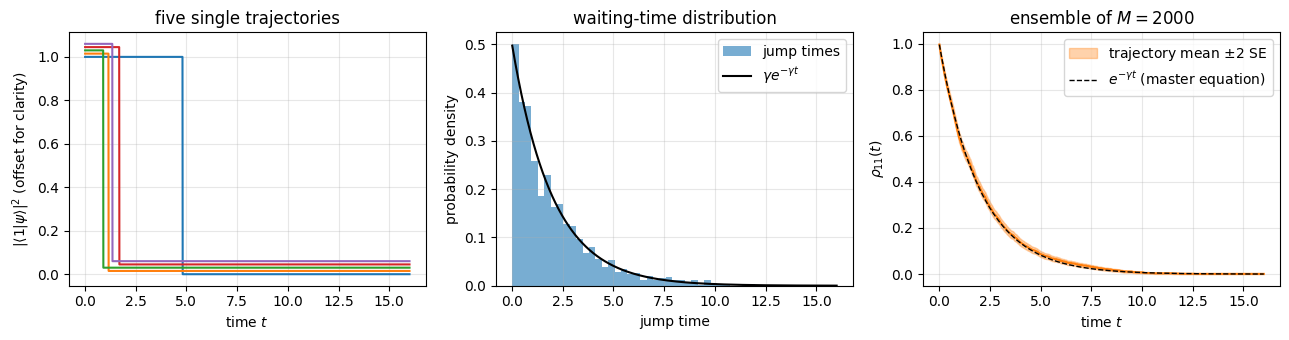

In [5]:
# ==============================================================================
# EXPERIMENT A: decay from |1>, no drive
# ==============================================================================
psi_excited = jnp.array([0, 1], dtype=CDTYPE)
bloch_A, jumps_A = qubit_trajectories(psi_excited, 0.0, jax.random.split(key_A, M_q))
p1_A = 0.5 * (1 - np.asarray(bloch_A[:, :, 2]))                      # rho_11 = (1 - <Z>)/2 for each trajectory and time
jumped = np.asarray(jumps_A).max(1) > 0                              # did the trajectory jump at all?
t_jump = dt_q * (np.asarray(jumps_A > 0).argmax(1) + 1)              # time of the (single) jump

p1_mean, p1_se = mean_and_se(p1_A)
ok = p1_se > 0
z_A = (p1_mean[ok] - np.exp(-gamma_q * t_q[ok])) / p1_se[ok]
print(f"trajectories that jumped before T: {jumped.mean():.4f}   (expected 1 - exp(-gamma T) = {1 - np.exp(-gamma_q * T_q):.4f})")
print(f"mean jump time = {t_jump[jumped].mean():.3f} +- {t_jump[jumped].std(ddof=1) / np.sqrt(jumped.sum()):.3f}   (expected ~ 1/gamma = {1 / gamma_q:.3f})")
print(f"values of p1 found in single trajectories: {np.unique(np.round(p1_A, 12))}")
print(f"ensemble average vs exp(-gamma t): max |deviation| = {np.abs(p1_mean - np.exp(-gamma_q * t_q)).max():.4f}, "
      f"max |deviation|/SE = {np.abs(z_A).max():.2f}")
assert np.abs(z_A).max() < 4.0

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for i in range(5):
    ax[0].plot(t_q, p1_A[i] + 0.015 * i, lw=1.5)
ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel(r"$|\langle1|\psi\rangle|^2$ (offset for clarity)"); ax[0].set_title("five single trajectories"); ax[0].grid(alpha=.3)
ax[1].hist(t_jump[jumped], bins=40, density=True, color="C0", alpha=.6, label="jump times")
ax[1].plot(t_q, gamma_q * np.exp(-gamma_q * t_q), "k-", label=r"$\gamma e^{-\gamma t}$")
ax[1].set_xlabel(r"jump time"); ax[1].set_ylabel("probability density"); ax[1].set_title("waiting-time distribution"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].fill_between(t_q, p1_mean - 2 * p1_se, p1_mean + 2 * p1_se, color="C1", alpha=.35, label=r"trajectory mean $\pm2$ SE")
ax[2].plot(t_q, p1_mean, "C1", lw=1.5)
ax[2].plot(t_q, np.exp(-gamma_q * t_q), "k--", lw=1, label=r"$e^{-\gamma t}$ (master equation)")
ax[2].set_xlabel(r"time $t$"); ax[2].set_ylabel(r"$\rho_{11}(t)$"); ax[2].set_title(rf"ensemble of $M={M_q}$"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** In every single run the excitation probability is either exactly 1 or exactly 0 (the printed list of
values) — no individual atom ever has "$\rho_{11}=0.37$". The smooth exponential of the master equation emerges only in
the average, as the fraction of atoms that have not yet jumped. The jump times follow $\gamma e^{-\gamma t}$, and the averaged
population agrees with $e^{-\gamma t}$ within the statistical error (largest deviation in units of the standard error printed above).

### 3.4 Experiment B: a superposition, where no click is information

Now start from $(|0\rangle+|1\rangle)/\sqrt2$. If a photon is detected the atom is in $|0\rangle$ afterwards — obviously. But what if
we watch and see *nothing*? The no-jump evolution multiplies the amplitude of $|1\rangle$ by $e^{-\gamma t/2}$ and leaves the amplitude of $|0\rangle$ alone; after renormalisation

$$ |\psi_{\text{no click}}(t)\rangle = \frac{|0\rangle+e^{-\gamma t/2}|1\rangle}{\sqrt{1+e^{-\gamma t}}},\qquad
   p_1^{\text{no click}}(t)=\frac{e^{-\gamma t}}{1+e^{-\gamma t}},\qquad P_{\text{no click}}(t)=\frac{1+e^{-\gamma t}}2 . \tag{5}$$

The longer we wait without a click, the more certain we become that the atom was in $|0\rangle$ all along: the state drifts
continuously to $|0\rangle$ *without any emission*. This is Bayesian updating, enforced by $H_{\rm eff}$. Half of all atoms never emit
($P_{\text{no click}}\to\tfrac12$), and still all of them end in $|0\rangle$.

no-click trajectory vs Eq. (5): max error = 7.28e-14
fraction of trajectories without a click: 0.5010 +- 0.0112   (Eq. (5): 0.5002)


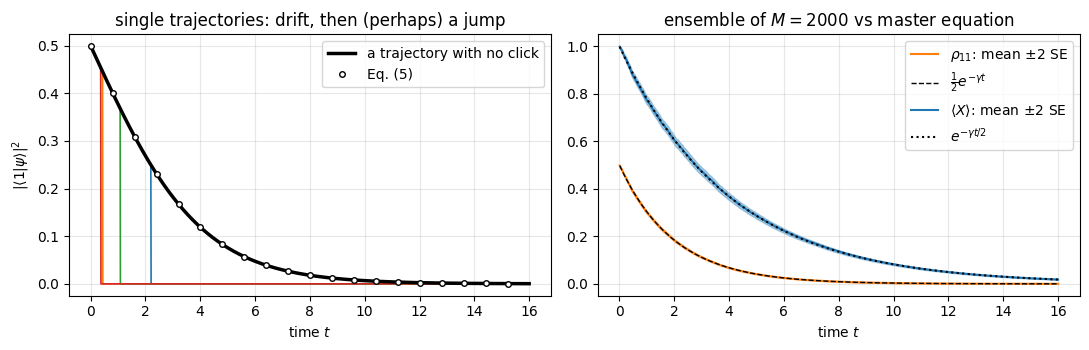

In [6]:
# ==============================================================================
# EXPERIMENT B: decay from (|0> + |1>)/sqrt(2), no drive
# ==============================================================================
psi_plus = jnp.array([1, 1], dtype=CDTYPE) / jnp.sqrt(2.0)
bloch_B, jumps_B = qubit_trajectories(psi_plus, 0.0, jax.random.split(key_B, M_q))
p1_B = 0.5 * (1 - np.asarray(bloch_B[:, :, 2]))
jumped_B = np.asarray(jumps_B).max(1) > 0

i_nc = int(np.flatnonzero(~jumped_B)[0])                             # index of a trajectory WITHOUT any click
p1_noclick_exact = np.exp(-gamma_q * t_q) / (1 + np.exp(-gamma_q * t_q))
err_nc = np.abs(p1_B[i_nc] - p1_noclick_exact).max()
frac_nc = 1 - jumped_B.mean()
frac_nc_exact = 0.5 * (1 + np.exp(-gamma_q * T_q))
print(f"no-click trajectory vs Eq. (5): max error = {err_nc:.2e}")
print(f"fraction of trajectories without a click: {frac_nc:.4f} +- {np.sqrt(frac_nc * (1 - frac_nc) / M_q):.4f}   (Eq. (5): {frac_nc_exact:.4f})")
assert err_nc < max(1e-6, TOL) and abs(frac_nc - frac_nc_exact) < 4 * np.sqrt(0.25 / M_q)

x_mean, x_se = mean_and_se(bloch_B[:, :, 0])
p1m_B, p1s_B = mean_and_se(p1_B)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for i in list(np.flatnonzero(jumped_B)[:4]):
    ax[0].plot(t_q, p1_B[i], lw=1.2)
ax[0].plot(t_q, p1_B[i_nc], "k", lw=2.5, label="a trajectory with no click")
ax[0].plot(t_q[::80], p1_noclick_exact[::80], "wo", mec="k", ms=4, label="Eq. (5)")
ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel(r"$|\langle1|\psi\rangle|^2$"); ax[0].set_title("single trajectories: drift, then (perhaps) a jump"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].fill_between(t_q, p1m_B - 2 * p1s_B, p1m_B + 2 * p1s_B, color="C1", alpha=.35); ax[1].plot(t_q, p1m_B, "C1", label=r"$\rho_{11}$: mean $\pm2$ SE")
ax[1].plot(t_q, 0.5 * np.exp(-gamma_q * t_q), "k--", lw=1, label=r"$\frac{1}{2}e^{-\gamma t}$")
ax[1].fill_between(t_q, x_mean - 2 * x_se, x_mean + 2 * x_se, color="C0", alpha=.35); ax[1].plot(t_q, x_mean, "C0", label=r"$\langle X\rangle$: mean $\pm2$ SE")
ax[1].plot(t_q, np.exp(-gamma_q * t_q / 2), "k:", lw=1.5, label=r"$e^{-\gamma t/2}$")
ax[1].set_xlabel(r"time $t$"); ax[1].set_title(rf"ensemble of $M={M_q}$ vs master equation"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* between $t=0$ and its jump every trajectory follows the same smooth no-click curve of Eq. (5) (thick line:
a run that never clicked, in agreement with the formula to the accuracy of RK4); a click sends it to $p_1=0$ instantly. About half of the runs never click.
*Right:* averaged over the ensemble, population and coherence follow the master-equation results $\tfrac12e^{-\gamma t}$ and $e^{-\gamma t/2}$
(previous notebook, $T_1$ and $T_2=2T_1$). The $T_2$ decay of $\langle X\rangle$ arises in two ways at once: partly from trajectories that jumped
(coherence gone), partly from the *drift* of those that did not.

> **Common pitfall.** A tempting "simplified" algorithm applies the unitary $e^{-iHdt}$ and then jumps with probability
> $\delta p=\gamma\,dt\,\langle L^\dagger L\rangle$, forgetting the non-Hermitian part of $H_{\rm eff}$. In experiment B it would leave
> $p_1=\tfrac12$ in every no-click run, so clicks would arrive at the constant rate $\gamma p_1=\gamma/2$ instead of the
> correct, decreasing $\gamma p_1(t)$; the ensemble would relax as $\rho_{11}=\tfrac12e^{-\gamma t/2}$, a $T_1$ twice too long
> (and, by coincidence for this initial state, the right $T_2$). The anticommutator term of the master equation lives in the
> no-jump evolution; without it the average is wrong, not just noisy. Exercise 2 measures it.

### 3.5 Experiment C: a driven qubit — Rabi oscillations interrupted by jumps

With a resonant drive, $H=\tfrac\Omega2X$, the ensemble shows damped Rabi oscillations towards the steady state
$z_{\rm ss}=\gamma^2/(\gamma^2+2\Omega^2)$ derived in the [previous notebook, Section 3.4](16_lindblad_master_equation.ipynb). The exact solution
of the optical Bloch equations, $\vec r(t)=\vec r_{\rm ss}+e^{Mt}(\vec r_0-\vec r_{\rm ss})$, serves as reference.

mean number of jumps per trajectory: 3.84   (steady-state estimate gamma*rho_11*T = 3.88)
<Z>: max |mean - exact| = 0.0417;   typical SE = 0.0155;   fraction of time points within 2 SE = 0.979;   max |dev|/SE = 2.36


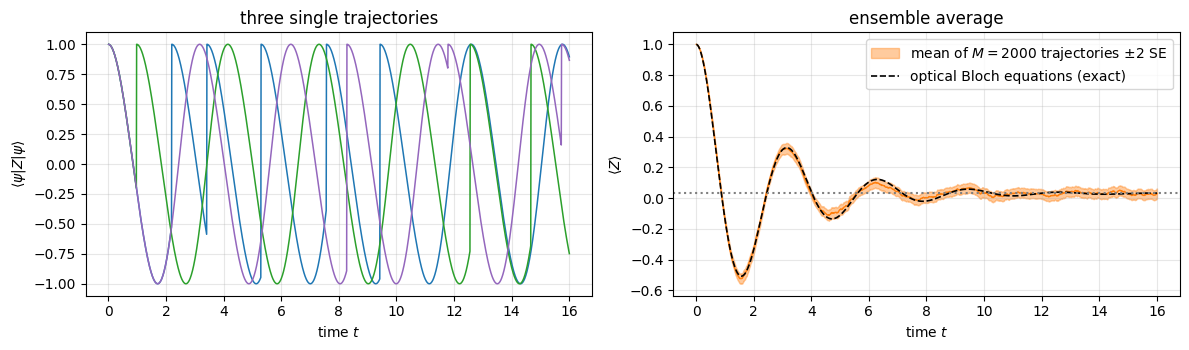

In [7]:
# ==============================================================================
# EXPERIMENT C: resonantly driven, decaying qubit, starting in |0>
# ==============================================================================
Omega_q = 2.0
bloch_C, jumps_C = qubit_trajectories(jnp.array([1, 0], dtype=CDTYPE), Omega_q, jax.random.split(key_C, M_q))
bC_mean, bC_se = mean_and_se(bloch_C)

# exact solution of the optical Bloch equations  dr/dt = M r + b
M_bloch = jnp.array([[-gamma_q / 2, 0, 0], [0, -gamma_q / 2, -Omega_q], [0, Omega_q, -gamma_q]], dtype=RDTYPE)
den = gamma_q ** 2 + 2 * Omega_q ** 2
r_ss = jnp.array([0.0, -2 * Omega_q * gamma_q / den, gamma_q ** 2 / den], dtype=RDTYPE)
bloch_exact = np.asarray(jax.vmap(lambda t: r_ss + jax.scipy.linalg.expm(M_bloch * t) @ (jnp.array([0.0, 0.0, 1.0], dtype=RDTYPE) - r_ss))(jnp.asarray(t_q, dtype=RDTYPE)))

sel = bC_se[:, 2] > 1e-3
z_C = (bC_mean[sel, 2] - bloch_exact[sel, 2]) / bC_se[sel, 2]
print(f"mean number of jumps per trajectory: {np.asarray(jumps_C > 0).sum(1).mean():.2f}   "
      f"(steady-state estimate gamma*rho_11*T = {gamma_q * Omega_q ** 2 / den * T_q:.2f})")
print(f"<Z>: max |mean - exact| = {np.abs(bC_mean[:, 2] - bloch_exact[:, 2]).max():.4f};   typical SE = {np.median(bC_se[:, 2]):.4f};   "
      f"fraction of time points within 2 SE = {np.mean(np.abs(z_C) < 2):.3f};   max |dev|/SE = {np.abs(z_C).max():.2f}")
assert np.abs(z_C).max() < 4.5

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for i, c in zip(range(3), ["C0", "C2", "C4"]):
    ax[0].plot(t_q, np.asarray(bloch_C[i, :, 2]) , color=c, lw=1.1)
ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel(r"$\langle\psi|Z|\psi\rangle$"); ax[0].set_title("three single trajectories"); ax[0].grid(alpha=.3)
ax[1].fill_between(t_q, bC_mean[:, 2] - 2 * bC_se[:, 2], bC_mean[:, 2] + 2 * bC_se[:, 2], color="C1", alpha=.4, label=rf"mean of $M={M_q}$ trajectories $\pm2$ SE")
ax[1].plot(t_q, bC_mean[:, 2], "C1", lw=1)
ax[1].plot(t_q, bloch_exact[:, 2], "k--", lw=1.2, label="optical Bloch equations (exact)")
ax[1].axhline(float(r_ss[2]), color="gray", ls=":")
ax[1].set_xlabel(r"time $t$"); ax[1].set_ylabel(r"$\langle Z\rangle$"); ax[1].set_title("ensemble average"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** A single driven atom performs **full-amplitude** Rabi oscillations — a pure state stays on the surface of the Bloch
sphere — that are reset to $|0\rangle$ ($\langle Z\rangle=+1$) by every emission, at random times. (Look closely: between jumps the oscillation is also slightly
distorted by the no-click drift.) Each reset shifts the phase of the oscillation by a random amount, and averaging over oscillations with random phases is what
produces the *damped* oscillation of the ensemble: the band reproduces the Bloch-equation solution within the error bars, including the mixed
steady state $\langle Z\rangle_{\rm ss}=\gamma^2/(\gamma^2+2\Omega^2)\approx0.03$ (dotted line) that no single trajectory ever approaches. Decoherence, in this picture, is
our ignorance of the jump times.

## 4. Many spins: `scan` over time, `vmap` over trajectories

### 4.1 The model, two steppers, and observables

From here on: the open XXZ chain in a transverse field of the [previous notebook](16_lindblad_master_equation.ipynb),

$$ H=\sum_{i=0}^{N-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta Z_iZ_{i+1}\big)+h_x\sum_iX_i,\qquad\text{one jump operator }L_i\text{ per site, rate }\gamma . $$

`make_steppers` prepares both steppers of Section 2.4 with the common signature `step(key, psi) -> (psi, m)`
(the engine's Trotter stepper does not report jumps; we return `m = 0`). Here is the engine function, verbatim — it is short:

```python
def lindblad_trotter_step_mcwf(key, psi, gates, jump_kraus):
    psi = apply_gates(psi, gates)                                   # unitary part: TEBD gates
    keys = jax.random.split(key, max(len(jump_kraus), 1))           # one key per jump operator
    for k, (q, K) in zip(keys, jump_kraus):
        psi = apply_kraus_mcwf(k, psi, K, q)                        # sample K_0 ("no jump") or K_1 ("jump"), renormalise
    return psi
```

As observables we take the six site-averaged quantities
$\bar X=\tfrac1N\sum_i\langle X_i\rangle$, $\bar Y$, $\bar Z$ and $\overline{XX}=\tfrac1{N-1}\sum_i\langle X_iX_{i+1}\rangle$, $\overline{YY}$, $\overline{ZZ}$.
Because they are linear in the state, we first *average the reduced density matrices* over sites/bonds and then take three traces each: $N+(N-1)$
partial traces per evaluation instead of $3N+3(N-1)$.

In [8]:
# ==============================================================================
# STEP 2: many-body set-up -- steppers and observables for pure states and for density tensors
# ==============================================================================
def make_steppers(terms, jumps, dt):
    """Return (step_rk4, step_trotter), both with signature step(key, psi) -> (psi, m)."""
    gates = tebd_gates(terms, dt, order=2)
    jump_kraus = [(q, kraus_from_jump(L, g * dt)) for q, L, g in jumps]
    step_rk4 = lambda k, p: mcwf_rk4_step(k, p, terms, jumps, dt)
    step_trotter = lambda k, p: (lindblad_trotter_step_mcwf(k, p, gates, jump_kraus), 0)
    return step_rk4, step_trotter


def _six_from_rdms(r1, r2):
    return jnp.real(jnp.stack([jnp.trace(r1 @ P) for P in (X, Y, Z)] + [jnp.trace(r2 @ PP) for PP in (XX, YY, ZZ)]))


def six_observables(psi):
    """Site-averaged (<X>, <Y>, <Z>, <XX>, <YY>, <ZZ>) of a PURE state (rank-N tensor)."""
    N = psi.ndim
    r1 = sum(rdm(psi, [q]) for q in range(N)) / N
    r2 = sum(rdm(psi, [q, q + 1]) for q in range(N - 1)) / (N - 1)
    return _six_from_rdms(r1, r2)


def six_observables_dm(rho):
    """The same six numbers from a density TENSOR (rank 2N)."""
    N = rho.ndim // 2
    r1 = sum(rdm_dm(rho, [q]) for q in range(N)) / N
    r2 = sum(rdm_dm(rho, [q, q + 1]) for q in range(N - 1)) / (N - 1)
    return _six_from_rdms(r1, r2)


def evolve_dm(step, rho0, n_steps, observe):
    """Density-tensor reference: iterate rho -> step(rho), record observe(rho) after every step (lax.scan)."""
    def body(rho, _):
        rho = step(rho)
        return rho, observe(rho)
    return lax.scan(body, rho0, None, length=n_steps)[1]


obs_names = [r"$\overline{X}$", r"$\overline{Y}$", r"$\overline{Z}$", r"$\overline{XX}$", r"$\overline{YY}$", r"$\overline{ZZ}$"]

### 4.2 Checkpoint on a small system: $N=4$ with decay *and* dephasing

Before the production run we test both steppers where everything is cheap: $N=4$, **two** jump operators per site
($\sigma^+$ with rate 0.2 and $Z$ with rate 0.1), initial state $|1{+}0{-}\rangle$ so that all observables are non-trivial. Reference:
the RK4 density-tensor evolution validated in the previous notebook. We print the final-time comparison and the
**pull** $(\bar O-O_{\rm ref})/\mathrm{SE}$, which should be of order one.

In [9]:
# ==============================================================================
# CHECKPOINT: N = 4, decay + dephasing, MCWF (both steppers) vs density-tensor RK4
# ==============================================================================
Nv, dt_v, T_v, M_v = 4, 0.05, 6.0, 2000
n_v = int(round(T_v / dt_v))
terms_v = heisenberg_terms(Nv, Jxx=1.0, Jyy=1.0, Jzz=0.5, hx=1.0)
jumps_v = [((q,), SP, 0.2) for q in range(Nv)] + [((q,), Z, 0.1) for q in range(Nv)]
psi0_v = product_state("1+0-")
step_rk4_v, step_trotter_v = make_steppers(terms_v, jumps_v, dt_v)

ref_v = np.asarray(jax.jit(lambda r: evolve_dm(lambda x: lindblad_rk4_step(x, terms_v, jumps_v, dt_v), r, n_v, six_observables_dm))(to_dm(psi0_v)))
keys_v = jax.random.split(key_val, 2 * M_v)
run_v = lambda step, keys: np.asarray(jax.jit(jax.vmap(lambda k: run_trajectory(step, psi0_v, k, n_v, six_observables)[0]))(keys))
traj_v = {"MCWF + RK4": run_v(step_rk4_v, keys_v[:M_v]), "MCWF + Trotter": run_v(step_trotter_v, keys_v[M_v:])}

print(f"N = {Nv}, M = {M_v} trajectories, t = {T_v:g};  reference = density-tensor RK4")
print(f"{'observable':>12s} {'reference':>10s} | " + " | ".join(f"{k:>16s} {'pull':>6s}" for k in traj_v))
worst = 0.0
for j, name in enumerate(["X", "Y", "Z", "XX", "YY", "ZZ"]):
    row = f"{name:>12s} {ref_v[-1, j]:+10.4f} | "
    for k, tr in traj_v.items():
        m, se = mean_and_se(tr[:, -1, j])
        row += f"{m:+9.4f}+-{se:.4f} {(m - ref_v[-1, j]) / se:+6.2f} | "
        worst = max(worst, abs(m - ref_v[-1, j]) / se)
    print(row)
print(f"largest |pull| at the final time: {worst:.2f}")
assert worst < 4.0

N = 4, M = 2000 trajectories, t = 6;  reference = density-tensor RK4
  observable  reference |       MCWF + RK4   pull |   MCWF + Trotter   pull
           X    -0.0081 |   -0.0071+-0.0031  +0.32 |   -0.0125+-0.0031  -1.41 | 
           Y    -0.0968 |   -0.1025+-0.0040  -1.43 |   -0.1028+-0.0041  -1.46 | 
           Z    +0.0351 |   +0.0400+-0.0041  +1.19 |   +0.0329+-0.0043  -0.52 | 
          XX    +0.0043 |   +0.0017+-0.0030  -0.84 |   +0.0005+-0.0031  -1.21 | 
          YY    +0.0110 |   +0.0093+-0.0035  -0.50 |   +0.0128+-0.0033  +0.54 | 
          ZZ    +0.0026 |   +0.0023+-0.0033  -0.12 |   +0.0021+-0.0033  -0.18 | 
largest |pull| at the final time: 1.46


All twelve estimates agree with the density-tensor reference within their error bars (pulls of order one; with 12 numbers
a value around 2 is expected to occur, a value above 4 would signal a bug). Both steppers handle several jump operators
per site, a non-Hermitian $L$, and a non-trivial initial state.

> **Numerical practice.** A stochastic code cannot be tested with `assert err < 1e-10`. Test it with *pulls*: deviations
> in units of the estimated standard error, with a fixed seed so that the test is reproducible. Systematic errors reveal
> themselves as pulls that grow like $\sqrt M$ when you increase $M$.

## 5. The 2x2 comparison: {density matrix, trajectories} x {RK4, Trotter}

The central experiment of this notebook. **Model:** XXZ chain, $\Delta=0.5$, $h_x=1$, $N=6$, **pure dephasing** $L_i=Z_i$ with
$\gamma=0.1$ on every site, initial state $|00\dots0\rangle$, $dt=0.05$, $T=10$, $M=1000$ trajectories. Four simulations of the *same* physics:

| | RK4 ("exact" in the splitting sense) | Trotter (gates + Kraus) |
|---|---|---|
| **density tensor**, $4^N$ numbers | `lindblad_rk4_step` | `lindblad_trotter_step_dm` |
| **trajectories**, $M\times2^N$ numbers | `mcwf_rk4_step` | `lindblad_trotter_step_mcwf` |

What should we expect? For dephasing, $L^\dagger L=Z^2=\mathbb 1$, so $H_{\rm eff}=H-\tfrac i2N\gamma$: the no-jump evolution is ordinary unitary
evolution (the uniform damping is removed by the renormalisation), and a jump is a $Z$ flip on a random site at rate $N\gamma$ —
trajectories are random *phase kicks*. Physically the coherences and with them all six observables should be damped towards their
value 0 in the maximally mixed state (previous notebook, Section 8).

The four methods differ by $O(dt)$ *and* by $O(1/\sqrt M)$, and it pays to be precise about which difference sits where.
Along the columns, RK4 and Trotter differ by the splitting error, $O(dt)$ and systematic. Down the **Trotter** column the two entries
have *identical* averages for any $dt$ (Section 2.4), so `MCWF + Trotter` versus `DM + Trotter` is a pure test of the statistics. Down the
**RK4** column they do not: `mcwf_rk4_step` takes one collective jump decision per step and can therefore miss a double click, so its
trajectory average carries its own $O(dt)$ bias (Section 2.7) on top of the $O(1/\sqrt M)$ noise. At $dt=0.05$ and $M=1000$ that bias is of
the same order as the error bars, so the `MCWF + RK4` row below cannot separate the two; Section 6 uses the Trotter pair for that reason.

**Timing protocol.** The density-tensor functions are called twice (first call = compilation + run, second call = run). For the
trajectories we do not waste a warm-up run: the $M=1000$ trajectories are computed as **two batches of 500** with different keys — the
first batch pays for compilation, the second is timed as pure run time.

In [10]:
# ==============================================================================
# PARAMETERS  (2x2 comparison)
# ==============================================================================
N       = 6         # spins
Delta   = 0.5       # ZZ anisotropy
hx      = 1.0       # transverse field
gamma   = 0.1       # dephasing rate per site
dt      = 0.05      # time step
T_max   = 10.0      # total time
M_batch = 500       # trajectories per batch; two batches -> M = 1000

n_steps = int(round(T_max / dt))
t_grid = dt * np.arange(1, n_steps + 1)
terms = heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=Delta, hx=hx)
jumps = [((q,), Z, gamma) for q in range(N)]
psi0 = zero_state(N)
step_rk4, step_trotter = make_steppers(terms, jumps, dt)
gates = tebd_gates(terms, dt, order=2)
jump_kraus = [(q, kraus_from_jump(L, g * dt)) for q, L, g in jumps]


def timed(f, *args):
    """Call f(*args), wait for the result (asynchronous dispatch!), return (result as numpy, seconds)."""
    t0 = time.perf_counter()
    out = f(*args)
    out.block_until_ready()
    return np.asarray(out), time.perf_counter() - t0


results, timing = {}, {}
# ------------------------------------------------------------------------------
# density tensor: RK4 and Trotter-Kraus
# ------------------------------------------------------------------------------
dm_rk4 = jax.jit(lambda r: evolve_dm(lambda x: lindblad_rk4_step(x, terms, jumps, dt), r, n_steps, six_observables_dm))
dm_trotter = jax.jit(lambda r: evolve_dm(lambda x: lindblad_trotter_step_dm(x, gates, jump_kraus), r, n_steps, six_observables_dm))
for name, f in [("DM + RK4", dm_rk4), ("DM + Trotter", dm_trotter)]:
    _, t_first = timed(f, to_dm(psi0))
    results[name], t_run = timed(f, to_dm(psi0))
    timing[name] = (t_first, t_run)
# ------------------------------------------------------------------------------
# trajectories: two batches of M_batch keys each
# ------------------------------------------------------------------------------
traj = {}
for name, step, k in [("MCWF + RK4", step_rk4, jax.random.split(key_22)[0]), ("MCWF + Trotter", step_trotter, jax.random.split(key_22)[1])]:
    f = jax.jit(jax.vmap(lambda kk: run_trajectory(step, psi0, kk, n_steps, six_observables)[0]))
    keys = jax.random.split(k, 2 * M_batch)
    batch1, t_first = timed(f, keys[:M_batch])
    batch2, t_run = timed(f, keys[M_batch:])
    traj[name] = np.concatenate([batch1, batch2])                  # shape (M, n_steps, 6)
    results[name] = traj[name].mean(0)
    timing[name] = (t_first, t_run)
M_total = 2 * M_batch

print(f"{'method':>16s} | {'first call [s]':>14s} | {'run [s]':>8s} | {'work done in the timed run':<40s}")
for name, (t_first, t_run) in timing.items():
    work = f"{n_steps} steps of one 4^{N} = {4 ** N} tensor" if name.startswith("DM") else f"{n_steps} steps of {M_batch} trajectories x 2^{N} = {2 ** N}"
    print(f"{name:>16s} | {t_first:14.2f} | {t_run:8.2f} | {work:<40s}")

          method | first call [s] |  run [s] | work done in the timed run              
        DM + RK4 |           4.72 |     1.05 | 200 steps of one 4^6 = 4096 tensor      
    DM + Trotter |           0.71 |     0.28 | 200 steps of one 4^6 = 4096 tensor      
      MCWF + RK4 |           5.34 |     3.63 | 200 steps of 500 trajectories x 2^6 = 64
  MCWF + Trotter |           3.89 |     2.13 | 200 steps of 500 trajectories x 2^6 = 64


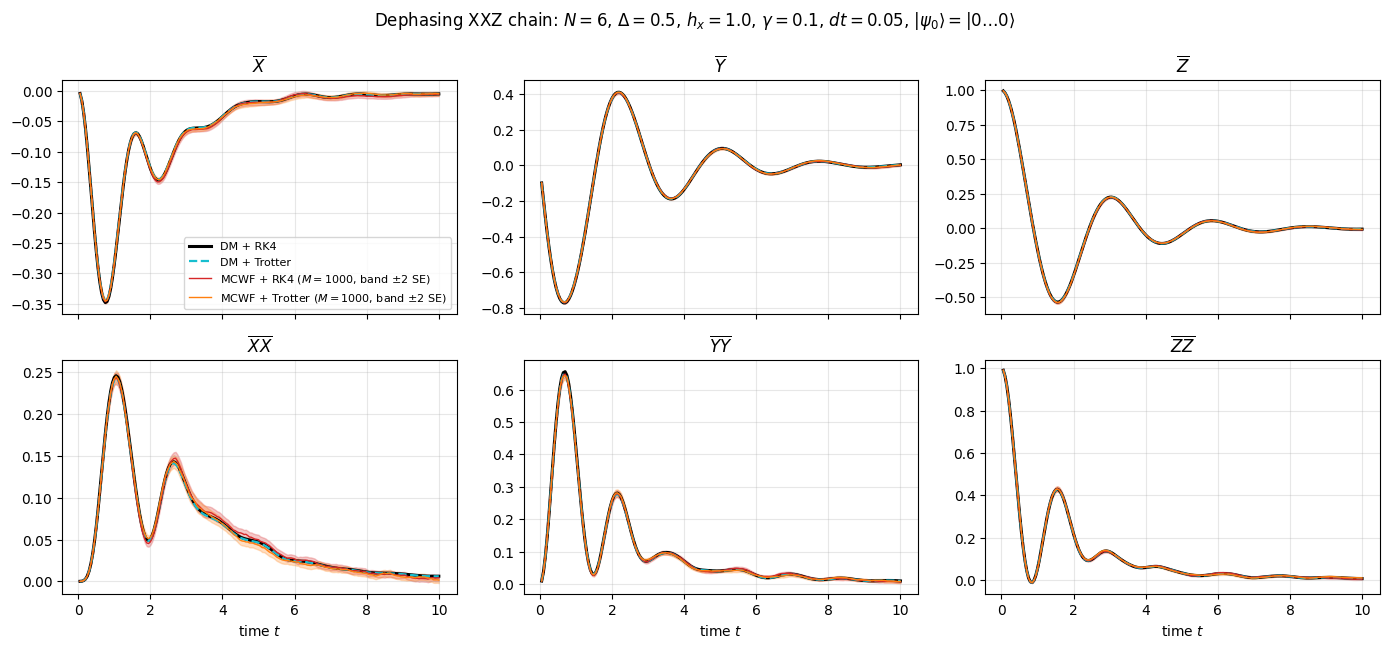

In [11]:
# ==============================================================================
# The 2x3 panel: six observables, four methods
# ==============================================================================
se_22 = {k: v.std(0, ddof=1) / np.sqrt(M_total) for k, v in traj.items()}
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharex=True)
for j, ax in enumerate(axes.ravel()):
    ax.plot(t_grid, results["DM + RK4"][:, j], color="k", lw=2.2, label="DM + RK4")
    ax.plot(t_grid, results["DM + Trotter"][:, j], color="C9", lw=1.6, ls="--", label="DM + Trotter")
    for name, c in [("MCWF + RK4", "C3"), ("MCWF + Trotter", "C1")]:
        m, s = results[name][:, j], se_22[name][:, j]
        ax.fill_between(t_grid, m - 2 * s, m + 2 * s, color=c, alpha=.25)
        ax.plot(t_grid, m, color=c, lw=1, label=rf"{name} ($M={M_total}$, band $\pm2$ SE)")
    ax.set_title(obs_names[j]); ax.grid(alpha=.3)
    if j >= 3:
        ax.set_xlabel(r"time $t$")
axes[0, 0].legend(fontsize=8)
fig.suptitle(rf"Dephasing XXZ chain: $N={N}$, $\Delta={Delta}$, $h_x={hx}$, $\gamma={gamma}$, $dt={dt}$, $|\psi_0\rangle=|0\ldots0\rangle$", y=0.99)
plt.tight_layout(); plt.show()

In [12]:
# ==============================================================================
# Numbers behind the figure: final values, systematic and statistical deviations
# ==============================================================================
gold = results["DM + RK4"]
print(f"final values at t = {T_max:g}")
print(f"{'':>6s} {'DM + RK4':>10s} {'DM + Trotter':>13s} {'MCWF + RK4':>20s} {'MCWF + Trotter':>20s}")
for j, name in enumerate(["X", "Y", "Z", "XX", "YY", "ZZ"]):
    print(f"{name:>6s} {gold[-1, j]:+10.5f} {results['DM + Trotter'][-1, j]:+13.5f} "
          + " ".join(f"{results[k][-1, j]:+10.5f}+-{se_22[k][-1, j]:.5f}" for k in traj))

sys_err = np.abs(results["DM + Trotter"] - gold).max()
print(f"\nsystematic (time-step) error:  max over t, observables |DM+Trotter - DM+RK4| = {sys_err:.2e}")
mask = t_grid >= 1.0                                   # at very early times all trajectories coincide and SE -> 0
for name, ref in [("MCWF + RK4", "DM + RK4"), ("MCWF + Trotter", "DM + Trotter")]:
    pull = (results[name] - results[ref])[mask] / se_22[name][mask]
    print(f"{name:>15s} vs {ref:<13s}: max |dev| = {np.abs(results[name] - results[ref]).max():.4f},  median SE = {np.median(se_22[name][mask]):.4f},  "
          f"rms pull = {np.sqrt(np.mean(pull ** 2)):.2f},  within 2 SE: {np.mean(np.abs(pull) < 2):.3f},  max |pull| = {np.abs(pull).max():.2f}")
    assert np.abs(pull).max() < 4.5 and np.sqrt(np.mean(pull ** 2)) < 1.5
assert sys_err < 2e-2

final values at t = 10
         DM + RK4  DM + Trotter           MCWF + RK4       MCWF + Trotter
     X   -0.00484      -0.00478   -0.00528+-0.00161   -0.00460+-0.00168
     Y   +0.00271      +0.00255   +0.00015+-0.00187   +0.00171+-0.00190
     Z   -0.00602      -0.00603   -0.01026+-0.00173   -0.00727+-0.00169
    XX   +0.00611      +0.00596   +0.00414+-0.00181   +0.00153+-0.00182
    YY   +0.01013      +0.00991   +0.00745+-0.00200   +0.00876+-0.00212
    ZZ   +0.00699      +0.00689   +0.00475+-0.00180   +0.01023+-0.00177

systematic (time-step) error:  max over t, observables |DM+Trotter - DM+RK4| = 6.18e-03
     MCWF + RK4 vs DM + RK4     : max |dev| = 0.0112,  median SE = 0.0021,  rms pull = 0.97,  within 2 SE: 0.977,  max |pull| = 2.45
 MCWF + Trotter vs DM + Trotter : max |dev| = 0.0060,  median SE = 0.0021,  rms pull = 0.83,  within 2 SE: 0.993,  max |pull| = 2.44


**Interpretation.**

* *Physics.* The chain starts fully polarised ($\bar Z=\overline{ZZ}=1$). The Hamiltonian drives coherent many-body oscillations, the
  dephasing damps them, and all six observables relax towards 0, their value in the maximally mixed state, as found in the previous
  notebook.
* *Columns (RK4 vs Trotter).* The two density-tensor curves lie on top of each other; their largest difference (printed) is of order
  $10^{-3}$–$10^{-2}$, the first-order splitting error at $dt=0.05$. It is *systematic*: it would shrink with $dt$, not with $M$.
* *Rows (density tensor vs trajectories).* The trajectory averages scatter around their density-tensor partners with the predicted standard error
  ($\approx0.002$–$0.01$ for $M=1000$): rms pull $\approx1$, about 95 % of all points within $2\,$SE. For the Trotter pair that is the whole story.
  For the RK4 pair the test is *blind* to a bias smaller than an error bar, and the $O(dt)$ bias of the collective jump decision is exactly that
  size here — a pull of order one is consistent both with "no bias" and with "a bias comparable to SE". At this $M$ the statistical error is
  comparable to or larger than every systematic one, so there would be no point in reducing $dt$ without increasing $M$.
* *Cost.* For $N=6$ the density tensor ($4^6=4096$ numbers) is *much* cheaper than 1000 state vectors ($64\,000$ numbers, and 200 steps of bookkeeping for each):
  trajectories are not a method for small systems. Section 8 shows where the balance tips.

> **Numerical practice.** Every simulation of an open system with trajectories has **two** error knobs: $dt$ (systematic) and $M$
> (statistical). Balance them: it is wasteful to push one far below the other.

## 6. Statistical error: the $1/\sqrt M$ law and how to test error bars

We have 1000 Trotter trajectories and the *exact* average of that stepper (`DM + Trotter`), so every deviation is purely statistical.
Two questions:

1. **Does the error decrease like $1/\sqrt M$?** Split the 1000 trajectories into $G=1000/M'$ disjoint groups of size $M'$, average each
   group, and measure the root-mean-square deviation from the reference (over groups and over times $t\ge1$). Prediction from Eq. (4): $\sqrt{\overline{s^2(t)}/M'}$.
2. **Calibration of the error bars.** For groups of $M'=50$ compute the pulls $(\bar O_{\rm group}-O_{\rm ref})/\mathrm{SE}_{\rm group}$. If Eq. (4) is right they
   are (nearly) standard normal: mean 0, standard deviation 1. We take time points $\Delta t=1$ apart to reduce correlations.

   M'   groups   rms error   predicted s/sqrt(M')
   10      100     0.02387      0.02412
   20       50     0.01627      0.01706
   50       20     0.01047      0.01079
  100       10     0.00788      0.00763
  200        5     0.00518      0.00539
  500        2     0.00327      0.00341
 1000        1     0.00180      0.00241
fitted exponent: error ~ M^(-0.539)   (expected -0.5)
pulls for groups of 50: n = 1200, mean = -0.006, std = 1.056, within 1 SE: 0.676 (Gaussian: 0.683), within 2 SE: 0.943 (0.954)


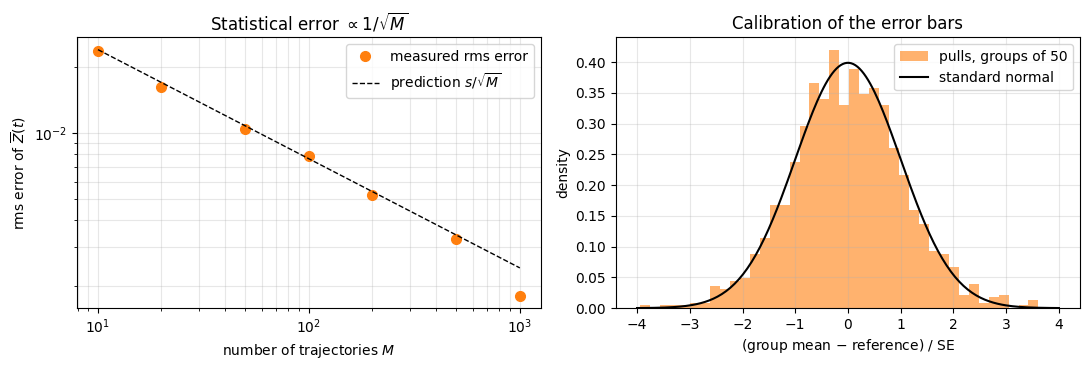

In [13]:
# ==============================================================================
# 1/sqrt(M) scaling and the distribution of pulls  (MCWF + Trotter vs its exact average, DM + Trotter)
# ==============================================================================
samples = traj["MCWF + Trotter"][:, mask, :]                         # (M, times, 6)
reference = results["DM + Trotter"][mask]
M_sub = [10, 20, 50, 100, 200, 500, 1000]
j_obs = 2                                                            # observable used for the scaling plot: site-averaged <Z>
rms_err, rms_pred = [], []
for Mp in M_sub:
    G = M_total // Mp
    group_means = samples[:G * Mp, :, j_obs].reshape(G, Mp, -1).mean(1)          # (G, times)
    rms_err.append(np.sqrt(np.mean((group_means - reference[:, j_obs]) ** 2)))
    rms_pred.append(np.sqrt(np.mean(samples[:, :, j_obs].var(0, ddof=1)) / Mp))
slope = np.polyfit(np.log(M_sub), np.log(rms_err), 1)[0]
print("   M'   groups   rms error   predicted s/sqrt(M')")
for Mp, e, p in zip(M_sub, rms_err, rms_pred):
    print(f"{Mp:5d} {M_total // Mp:8d} {e:11.5f} {p:12.5f}")
print(f"fitted exponent: error ~ M^({slope:.3f})   (expected -0.5)")
assert abs(slope + 0.5) < 0.12

Mp = 50
G = M_total // Mp
stride = int(round(1.0 / dt))
grp = samples[:, ::stride, :].reshape(G, Mp, -1, 6)
pulls = ((grp.mean(1) - reference[::stride]) / (grp.std(1, ddof=1) / np.sqrt(Mp))).ravel()
print(f"pulls for groups of {Mp}: n = {pulls.size}, mean = {pulls.mean():+.3f}, std = {pulls.std():.3f}, within 1 SE: {np.mean(np.abs(pulls) < 1):.3f} (Gaussian: 0.683), "
      f"within 2 SE: {np.mean(np.abs(pulls) < 2):.3f} (0.954)")
assert abs(pulls.mean()) < 0.15 and 0.85 < pulls.std() < 1.2

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].loglog(M_sub, rms_err, "o", color="C1", ms=7, label="measured rms error")
ax[0].loglog(M_sub, rms_pred, "k--", lw=1, label=r"prediction $s/\sqrt{M}$")
ax[0].set_xlabel(r"number of trajectories $M$"); ax[0].set_ylabel(r"rms error of $\overline{Z}(t)$"); ax[0].set_title(r"Statistical error $\propto1/\sqrt{M}$")
ax[0].legend(); ax[0].grid(alpha=.3, which="both")
xs = np.linspace(-4, 4, 200)
ax[1].hist(pulls, bins=40, density=True, color="C1", alpha=.6, label=rf"pulls, groups of {Mp}")
ax[1].plot(xs, np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi), "k-", label="standard normal")
ax[1].set_xlabel(r"(group mean $-$ reference) / SE"); ax[1].set_ylabel("density"); ax[1].set_title("Calibration of the error bars")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* the measured error follows the prediction $s/\sqrt M$ over two decades (the rightmost points are averages over
very few groups and therefore noisy themselves). *Right:* the pulls are distributed like a standard normal variable — the error bars
computed from Eq. (4) mean what they claim. (A standard deviation slightly above 1 is expected: with 50 samples the SE is itself estimated,
which turns the Gaussian into a Student-$t$ distribution — for groups of 50 the expected standard deviation is $\sqrt{49/47}=1.02$.)
Two correlations to keep in mind when reading the left panel: all seven points are built from the *same* 1000 trajectories, so they are not
independent measurements of the exponent, and the deviations at nearby times come from the same trajectories as well. The effective number of
independent samples behind the fitted exponent is therefore much smaller than the number of plotted points, and a fitted value a few hundredths
away from $-1/2$ carries no information.

> **Physics insight.** Site-averaged observables of a long chain *self-average*: $\bar Z=\tfrac1N\sum_iZ_i$ fluctuates less from trajectory to trajectory
> when $N$ is larger, because distant sites experience independent noise. Large systems need *fewer* trajectories for
> such **intensive** quantities — the opposite of what happens to the cost of the density matrix. The statement is about intensive
> observables only: for the **extensive** $\hat n=\sum_i|1\rangle\langle1|_i$ of Sections 7 and 8.3 the same independence gives
> $s\sim\sqrt N$, so a fixed *absolute* accuracy costs $M\propto N$ (Section 2.6).

## 7. Single trajectories of a many-body system: staircases, clicks, hidden entanglement

To *see* quantum jumps in a chain we choose a model in which nothing else changes the monitored quantity. Switch off the field, $h_x=0$:
the XXZ Hamiltonian then conserves the number of excitations $\hat n=\sum_i|1\rangle\langle1|_i$. With decay $L_i=\sigma^+_i$ on every
site, $\hat n$ changes **only** through jumps, by exactly $-1$ per click. Start from the fully excited chain $|11\dots1\rangle$.

**Exact results** (valid for any $N$ — we shall use them again in Section 8). In the Heisenberg picture
$\tfrac d{dt}\langle\hat n\rangle = i\langle[H,\hat n]\rangle+\gamma\sum_i\langle\sigma^-_i\hat n\sigma^+_i-\tfrac12\{\sigma^-_i\sigma^+_i,\hat n\}\rangle$. The commutator
vanishes, and $\sigma_i^-\hat n\,\sigma_i^+ = (\hat n-1)\,\sigma^-_i\sigma^+_i$ (the jump removes one excitation), so the bracket is
$-\sigma_i^-\sigma_i^+=-|1\rangle\langle1|_i$ and

$$ \frac{d\langle\hat n\rangle}{dt}=-\gamma\langle\hat n\rangle\quad\Longrightarrow\quad\langle\hat n\rangle(t)=\langle\hat n\rangle(0)\,e^{-\gamma t}. \tag{6}$$

Moreover, for the initial state $|1\dots1\rangle$ the density matrix stays a **product state**
$\rho(t)=\bigotimes_i\big[(1-e^{-\gamma t})|0\rangle\langle0|+e^{-\gamma t}|1\rangle\langle1|\big]$ at all times. Reason: with $a=1-e^{-\gamma t}$, $b=e^{-\gamma t}$ this
product equals $a^N(b/a)^{\hat n}$, a function of the conserved $\hat n$ alone; it commutes with $H$, so the Hamiltonian drops out of Eq. (1) and every site decays independently.
The ensemble contains **no correlations and no entanglement at all**. What do single trajectories do?

We use stepper A (it reports the click channel $m$) with $N=8$, $\gamma=0.2$, and record $\langle\hat n\rangle$, the half-chain entanglement
entropy of $|\psi\rangle$ (`entanglement_entropy`, from the Schmidt decomposition) and the clicks.

<n> in single trajectories is an integer at all times: max distance to an integer = 3.6e-15
clicks per trajectory: mean = 7.835   (expected N (1 - exp(-gamma T)) = 7.853)
ensemble <n>(t) vs Eq. (6): max |dev| = 0.105, max |dev|/SE = 1.72
half-chain entanglement entropy of trajectories: max over time of the mean = 2.042 bits;  of rho(t): 0 (product state)


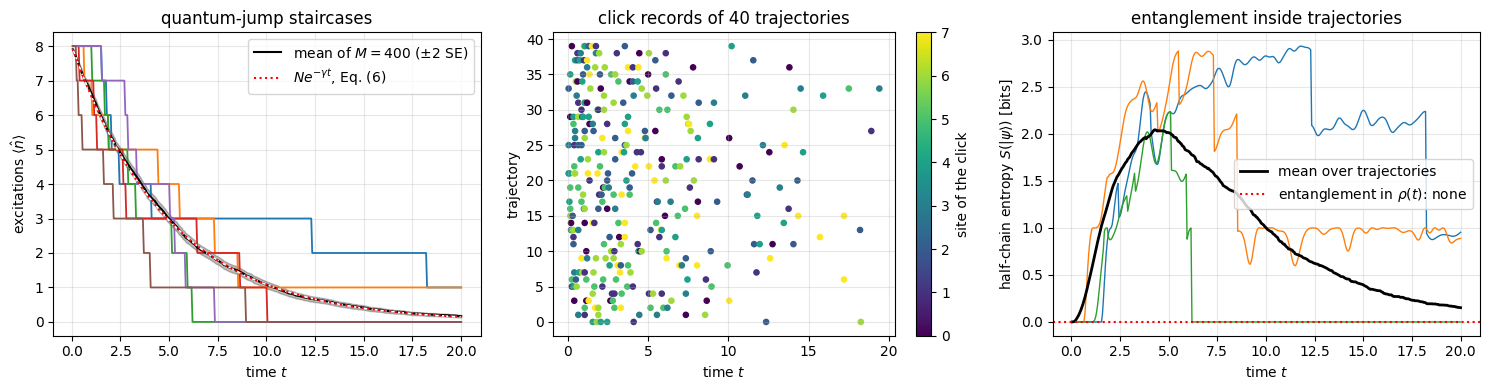

In [14]:
# ==============================================================================
# PARAMETERS  (quantum-jump staircases)
# ==============================================================================
N_s, gamma_s, dt_s, T_s, M_s = 8, 0.2, 0.05, 20.0, 400
n_s = int(round(T_s / dt_s))
t_s = dt_s * np.arange(1, n_s + 1)
terms_s = heisenberg_terms(N_s, Jxx=1.0, Jyy=1.0, Jzz=0.5)                    # hx = 0: excitation number conserved by H
jumps_s = [((q,), SP, gamma_s) for q in range(N_s)]
step_s, _ = make_steppers(terms_s, jumps_s, dt_s)


def z_profile(psi):
    """<Z_q> for all q from the probabilities |psi|^2 alone (Z is diagonal): marginal of axis q, then p(0) - p(1).
    COST  N reductions of a real array -- cheaper than N reduced density matrices."""
    prob = jnp.abs(psi) ** 2
    N = psi.ndim
    marg = [jnp.sum(prob, axis=tuple(a for a in range(N) if a != q)) for q in range(N)]
    return jnp.stack([m[0] - m[1] for m in marg])


def staircase_observables(psi):
    """(number of excitations <n> = sum_q (1 - <Z_q>)/2,  half-chain entanglement entropy in bits)."""
    n_exc = jnp.sum(0.5 * (1.0 - z_profile(psi)))
    return jnp.stack([n_exc, entanglement_entropy(psi, range(psi.ndim // 2))])


obs_s, clicks_s = jax.jit(jax.vmap(lambda k: run_trajectory(step_s, basis_state([1] * N_s), k, n_s, staircase_observables)))(jax.random.split(key_stair, M_s))
obs_s, clicks_s = np.asarray(obs_s), np.asarray(clicks_s)

n_mean, n_se = mean_and_se(obs_s[:, :, 0])
n_exact = N_s * np.exp(-gamma_s * t_s)
pull_n = (n_mean - n_exact)[n_se > 0] / n_se[n_se > 0]
dist_to_integer = np.abs(obs_s[:, :, 0] - np.round(obs_s[:, :, 0])).max()
print(f"<n> in single trajectories is an integer at all times: max distance to an integer = {dist_to_integer:.1e}")
print(f"clicks per trajectory: mean = {(clicks_s > 0).sum(1).mean():.3f}   (expected N (1 - exp(-gamma T)) = {N_s * (1 - np.exp(-gamma_s * T_s)):.3f})")
print(f"ensemble <n>(t) vs Eq. (6): max |dev| = {np.abs(n_mean - n_exact).max():.3f}, max |dev|/SE = {np.abs(pull_n).max():.2f}")
print(f"half-chain entanglement entropy of trajectories: max over time of the mean = {obs_s[:, :, 1].mean(0).max():.3f} bits;  of rho(t): 0 (product state)")
assert dist_to_integer < 1e-6 and np.abs(pull_n).max() < 4.0

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i in range(6):
    ax[0].plot(t_s, obs_s[i, :, 0], lw=1.3)
ax[0].fill_between(t_s, n_mean - 2 * n_se, n_mean + 2 * n_se, color="k", alpha=.25)
ax[0].plot(t_s, n_mean, "k", lw=1.5, label=rf"mean of $M={M_s}$ ($\pm2$ SE)")
ax[0].plot(t_s, n_exact, "w--", lw=1.2); ax[0].plot(t_s, n_exact, "r:", lw=1.5, label=r"$N e^{-\gamma t}$, Eq. (6)")
ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel(r"excitations $\langle\hat n\rangle$"); ax[0].set_title("quantum-jump staircases"); ax[0].legend(); ax[0].grid(alpha=.3)
n_show = 40
tr_idx, st_idx = np.nonzero(clicks_s[:n_show] > 0)
sc = ax[1].scatter(t_s[st_idx], tr_idx, c=clicks_s[:n_show][tr_idx, st_idx] - 1, cmap="viridis", s=14)
plt.colorbar(sc, ax=ax[1], label="site of the click")
ax[1].set_xlabel(r"time $t$"); ax[1].set_ylabel("trajectory"); ax[1].set_title(f"click records of {n_show} trajectories"); ax[1].grid(alpha=.3)
for i in range(3):
    ax[2].plot(t_s, obs_s[i, :, 1], lw=1)
ax[2].plot(t_s, obs_s[:, :, 1].mean(0), "k", lw=2, label="mean over trajectories")
ax[2].axhline(0, color="r", ls=":", lw=1.5, label=r"entanglement in $\rho(t)$: none")
ax[2].set_xlabel(r"time $t$"); ax[2].set_ylabel(r"half-chain entropy $S(|\psi\rangle)$ [bits]"); ax[2].set_title("entanglement inside trajectories"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.**

* *Left.* In every run the number of excitations is an integer that drops by one at each click: a **staircase**, different in every
  run. Between clicks $\hat n$ is constant, because $H$ and the no-jump damping $e^{-\gamma\hat n\,dt/2}$ both commute with $\hat n$. The average of the
  staircases is the smooth exponential (6), within error bars.
* *Middle.* The click record — what a photodetector array would actually register. Clicks are dense at early times (rate $\gamma n$) and die out as the chain empties.
* *Right.* After the first click at site $j$ the chain contains one *hole*, initially localised at the known site $j$. The exchange term $X_iX_{i+1}+Y_iY_{i+1}$ makes it
  hop, the hole delocalises, and the two halves of the chain become **entangled**: the trajectory-averaged half-chain entropy peaks at $2.0$ bits around $t\approx5$
  (single runs exceed $3$ of the $4$ bits this cut can carry), and then falls back to zero as the chain empties into the product state $|0\dots0\rangle$ — the entropy
  is largest when the excitations are neither all there nor all gone. The density matrix $\rho(t)$ of this very same process is an uncorrelated product state at all
  times. There is no contradiction: entanglement entropy is *nonlinear* in the state, so its trajectory average is not a property of
  $\rho$ (Section 2.5), and nothing forces the two to agree.

Three statements make the distinction precise, and none of them may be skipped when such a plot is reported.

1. The number plotted is $\overline{S(|\psi_i\rangle)}$, the average over the *photon-counting* unravelling. A different measurement of the
   environment (homodyne, Section 2.5) produces different trajectories with the same $\rho(t)$ and, in general, a different curve. The
   curve is a property of the measurement scheme, not of the open system alone.
2. It is an **upper bound**, not an estimate of the entanglement of $\rho$. Any unravelling realises $\rho(t)$ as an ensemble of pure states
   $\{p_i,|\psi_i\rangle\}$, and the entanglement of formation of $\rho$ is by definition the *minimum* of $\sum_ip_iS(|\psi_i\rangle)$ over all
   such decompositions (Bennett, DiVincenzo, Smolin and Wootters). Hence
   $E_F(\rho)\le\overline{S(|\psi_i\rangle)}$ for every unravelling. Here $\rho$ is a product state, $E_F=0$, and the bound $2.0$ bits is
   as far from tight as it can be — which is precisely the lesson.
3. What the curve *does* measure is the entanglement of the monitored system, conditioned on a detection record. That is a physical
   quantity for an experiment that records the clicks, and the competition between the entangling Hamiltonian and the disentangling
   measurements is the subject of the **measurement-induced entanglement transitions** studied since 2018.

## 8. Memory and time: the break-even point

### 8.1 Cost model

One step costs about the same number $c\,N$ of local contractions in both representations; each contraction touches every stored number once:

$$ t_{\rm DM}\approx c\,N\,4^N,\qquad t_{\rm MCWF}\approx M\,c'\,N\,2^N \qquad\Longrightarrow\qquad M_{\rm break\text{-}even}\sim2^N . $$

The number of trajectories needed for a fixed statistical accuracy on an *intensive* observable does not depend on $N$ (Section 2.6) — a few
hundred to a few thousand; for an extensive observable it grows only like $N$, which does not change the conclusion. Hence
the density tensor wins for $N\lesssim10$, trajectories win beyond, and above $N\approx13$–$14$ the question is moot because $\rho$ no longer fits into memory:

In [15]:
# ==============================================================================
# Memory: density tensor (one copy) versus M state vectors  (bytes per number taken from CDTYPE)
# ==============================================================================
def fmt_bytes(b):
    for unit in ["B", "kB", "MB", "GB", "TB", "PB"]:
        if b < 1000:
            return f"{b:6.1f} {unit}"
        b /= 1000
    return f"{b:6.1f} EB"

itemsize = jnp.zeros((), dtype=CDTYPE).dtype.itemsize
print(f"{'N':>3s} {'density tensor 4^N':>20s} {'1 trajectory 2^N':>18s} {'100 trajectories':>18s} {'1000 trajectories':>18s}")
for n in [6, 8, 10, 12, 14, 16, 18, 20, 24]:
    print(f"{n:3d} {fmt_bytes(itemsize * 4 ** n):>20s} {fmt_bytes(itemsize * 2 ** n):>18s} {fmt_bytes(100 * itemsize * 2 ** n):>18s} {fmt_bytes(1000 * itemsize * 2 ** n):>18s}")

  N   density tensor 4^N   1 trajectory 2^N   100 trajectories  1000 trajectories
  6              65.5 kB             1.0 kB           102.4 kB             1.0 MB
  8               1.0 MB             4.1 kB           409.6 kB             4.1 MB
 10              16.8 MB            16.4 kB             1.6 MB            16.4 MB
 12             268.4 MB            65.5 kB             6.6 MB            65.5 MB
 14               4.3 GB           262.1 kB            26.2 MB           262.1 MB
 16              68.7 GB             1.0 MB           104.9 MB             1.0 GB
 18               1.1 TB             4.2 MB           419.4 MB             4.2 GB
 20              17.6 TB            16.8 MB             1.7 GB            16.8 GB
 24               4.5 PB           268.4 MB            26.8 GB           268.4 GB


At $N=16$ one copy of $\rho$ needs 69 GB (RK4 would need several), while 100 trajectories need 105 MB. Trajectories need not even be held in memory simultaneously: they
are independent, so they can be processed in batches, or on different devices.

### 8.2 Measured time per step

We time one jitted Trotter step of the decaying XXZ chain: on the density tensor for $N\le8$ (beyond that the tensor gets uncomfortably large), and on a `vmap`-batch of $M_b=16$ trajectories up to
$N=14$. The ratio $t_{\rm DM}/t_{\rm trajectory}$ is the break-even number of trajectories.

  N |  DM step [ms] |  trajectory step [ms] |  break-even M = ratio |     2^N
  4 |         0.093 |                0.1032 |                   0.9 |      16
  6 |         0.632 |                0.0220 |                  28.7 |      64
  8 |         6.626 |                0.0695 |                  95.3 |     256
 10 |            -- |                0.2650 |                    -- |    1024
 12 |            -- |                0.7617 |                    -- |    4096
 14 |            -- |                3.4767 |                    -- |   16384


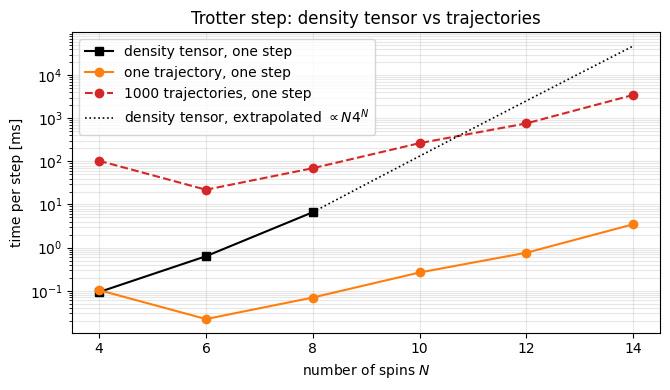

In [16]:
# ==============================================================================
# BENCHMARK: one Trotter step, density tensor vs batch of trajectories
# ==============================================================================
def bench_setup(Nb, dt_b=0.05, g=0.1):
    terms_b = heisenberg_terms(Nb, Jxx=1.0, Jyy=1.0, Jzz=0.5)
    gates_b = tebd_gates(terms_b, dt_b, order=2)
    jk_b = [((q,), kraus_from_jump(SP, g * dt_b)) for q in range(Nb)]
    return gates_b, jk_b, basis_state([1] * (Nb // 2) + [0] * (Nb - Nb // 2))


def time_fn(f, x, repeats):
    """Return (time of the first call incl. compilation, average run time of `repeats` further calls)."""
    t0 = time.perf_counter(); y = f(*x); jax.block_until_ready(y); t_first = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(repeats):
        y = f(*x)
    jax.block_until_ready(y)
    return t_first, (time.perf_counter() - t0) / repeats


M_b = 16
bench_dm, bench_mc = {}, {}
for Nb in [4, 6, 8]:
    gates_b, jk_b, psi_b = bench_setup(Nb)
    f = jax.jit(lambda r: lindblad_trotter_step_dm(r, gates_b, jk_b))
    bench_dm[Nb] = time_fn(f, (to_dm(psi_b),), repeats=5)
for Nb in [4, 6, 8, 10, 12, 14]:
    gates_b, jk_b, psi_b = bench_setup(Nb)
    f = jax.jit(jax.vmap(lambda k, p: lindblad_trotter_step_mcwf(k, p, gates_b, jk_b)))
    batch = jnp.broadcast_to(psi_b, (M_b,) + psi_b.shape)
    bench_mc[Nb] = time_fn(f, (jax.random.split(jax.random.PRNGKey(Nb), M_b), batch), repeats=5)

print(f"{'N':>3s} | {'DM step [ms]':>13s} | {'trajectory step [ms]':>21s} | {'break-even M = ratio':>21s} | {'2^N':>7s}")
for Nb in sorted(bench_mc):
    t_tr = 1e3 * bench_mc[Nb][1] / M_b
    if Nb in bench_dm:
        t_dm = 1e3 * bench_dm[Nb][1]
        print(f"{Nb:3d} | {t_dm:13.3f} | {t_tr:21.4f} | {t_dm / t_tr:21.1f} | {2 ** Nb:7d}")
    else:
        print(f"{Nb:3d} | {'--':>13s} | {t_tr:21.4f} | {'--':>21s} | {2 ** Nb:7d}")

fig, ax = plt.subplots(figsize=(6.8, 4))
Ns_dm, Ns_mc = np.array(sorted(bench_dm)), np.array(sorted(bench_mc))
ax.semilogy(Ns_dm, [1e3 * bench_dm[n][1] for n in Ns_dm], "s-", color="k", label="density tensor, one step")
ax.semilogy(Ns_mc, [1e3 * bench_mc[n][1] / M_b for n in Ns_mc], "o-", color="C1", label="one trajectory, one step")
ax.semilogy(Ns_mc, [1e3 * bench_mc[n][1] / M_b * 1000 for n in Ns_mc], "o--", color="C3", label="1000 trajectories, one step")
# extrapolate the density-tensor cost with the model  t ~ N 4^N  (anchored at the largest measured N) -- it cannot be run
n_ext = np.arange(Ns_dm[-1], Ns_mc[-1] + 1)
t_ext = 1e3 * bench_dm[Ns_dm[-1]][1] * (n_ext / Ns_dm[-1]) * 4.0 ** (n_ext - Ns_dm[-1])
ax.semilogy(n_ext, t_ext, ":", color="k", lw=1.2, label=r"density tensor, extrapolated $\propto N4^N$")
ax.set_xlabel(r"number of spins $N$"); ax.set_ylabel("time per step [ms]"); ax.set_title("Trotter step: density tensor vs trajectories")
ax.legend(); ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

**Interpretation.** (Absolute numbers depend on the machine and on its load; look at the trends.) For small $N$ both curves are flat — tiny arrays, the
time is per-operation overhead, and `vmap` amortises that overhead over the batch, which is why a single trajectory appears almost free. Once the arrays are large the
density-tensor step grows much faster with $N$ than the trajectory step — $4^N$ against $2^N$, exactly as the cost model says. The consequence is the fourth column: the break-even number of
trajectories climbs from a handful at $N=4$ to of order a hundred at $N=8$, in line with the rule $M_{\rm break\text{-}even}\sim2^N$. Do not read the individual entries literally, though:
at small $N$ both steps are dominated by fixed per-operation overheads, and these notes are executed on a shared CPU, so this benchmark can show the *trend* but not pin down the prefactor.

The last column of the figure is an **extrapolation, not a measurement**: the density-tensor curve is continued beyond the largest $N$ we can
actually run ($N=8$) with the model $t\propto N4^N$, anchored at that point. Three assumptions go into it — that the cost really is
proportional to the number of stored entries times the number of local terms, that the prefactor measured at $N=8$ (where the tensor is
1 MB and fits in cache) still applies at $N=11$ (where it is 64 MB and does not), and that the *measured* trajectory timings, which do reach
$N=14$, are representative. Under those assumptions 1000 trajectories become cheaper than the density tensor at $N\approx11$; the crossing in
the figure moves by a spin or so between runs, and the cache argument makes the true crossing if anything *earlier* than the dotted line
suggests. Either way it falls shortly before the density tensor stops fitting into memory at all.

> **JAX practice.** This benchmark is CPU-only, which is the pessimistic case for trajectories. A `vmap` batch of trajectories is a large,
> perfectly regular, branch-free batch of identical small tensor contractions — the workload GPUs are built for — whereas a single density
> tensor of the same physical system is one big array that quickly exceeds device memory. On a GPU the trajectory curve therefore flattens out
> over a wide range of batch sizes and the break-even $N$ moves down. Timings measured on one device never transfer to another; re-run the cell.

### 8.3 Beyond the density-matrix wall: a dissipative domain wall with $N=16$ spins

The finale: an open chain of $N=16$ spins. Its density tensor would need $4^{16}\times16$ bytes $=69$ GB. We prepare a **domain wall**
$|1\dots1\,0\dots0\rangle$ (left half excited), let it melt under the XXZ Hamiltonian ($h_x=0$) while every site decays with $\gamma=0.2$, and follow the
magnetisation profile $\langle Z_q(t)\rangle$ with the engine's Trotter stepper. No reference density matrix exists, but Eq. (6) does: the total number of
excitations must follow $\langle\hat n\rangle(t)=\tfrac N2e^{-\gamma t}$ **exactly**, for interacting spins and any $N$. A many-body checkpoint at a size where
nothing else is available.

The time step is $dt=0.1$, larger than anywhere else in this notebook. At $t=0$ the chain holds $N/2=8$ excitations, so
$\delta p=\gamma\,dt\,\langle\hat n\rangle=0.16$ clicks are expected per step — above the $0.1$ of Section 2.7, and therefore too large for
stepper A, which allows only one click per step. The engine's Trotter stepper decides each of the 16 channels independently and has no such
restriction; its own bias is the one quantified below.

N = 16: 24 trajectories x 40 steps in 17.2 s (including compilation);  memory of the batch: 25.2 MB  vs  density tensor: 68.7 GB
<n>(T) = 3.333 +- 0.274   exact: 3.595;   max |dev|/SE over all times = 1.06


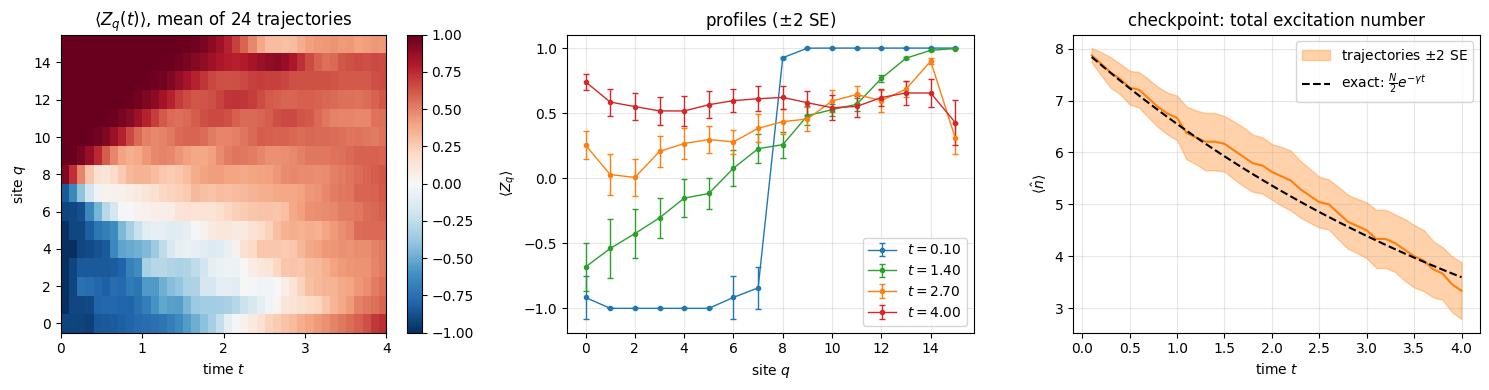

In [17]:
# ==============================================================================
# PARAMETERS  (N = 16 dissipative domain-wall melting)
# ==============================================================================
N_big, gamma_big, dt_big, T_big, M_big = 16, 0.2, 0.1, 4.0, 24
n_big = int(round(T_big / dt_big))
t_big = dt_big * np.arange(1, n_big + 1)
terms_big = heisenberg_terms(N_big, Jxx=1.0, Jyy=1.0, Jzz=0.5)
jumps_big = [((q,), SP, gamma_big) for q in range(N_big)]
_, step_big = make_steppers(terms_big, jumps_big, dt_big)
psi0_big = basis_state([1] * (N_big // 2) + [0] * (N_big - N_big // 2))

run_big = jax.jit(jax.vmap(lambda k: run_trajectory(step_big, psi0_big, k, n_big, z_profile)[0]))
zprof, t_big_run = timed(run_big, jax.random.split(key_big, M_big))                 # (M, n_steps, N)
print(f"N = {N_big}: {M_big} trajectories x {n_big} steps in {t_big_run:.1f} s (including compilation);  "
      f"memory of the batch: {fmt_bytes(M_big * itemsize * 2 ** N_big).strip()}  vs  density tensor: {fmt_bytes(itemsize * 4 ** N_big).strip()}")

n_traj = 0.5 * (1 - zprof).sum(2)                                                   # <n> per trajectory and time
nb_mean, nb_se = mean_and_se(n_traj)
nb_exact = 0.5 * N_big * np.exp(-gamma_big * t_big)
okb = nb_se > 0
pull_big = (nb_mean - nb_exact)[okb] / nb_se[okb]
print(f"<n>(T) = {nb_mean[-1]:.3f} +- {nb_se[-1]:.3f}   exact: {nb_exact[-1]:.3f};   max |dev|/SE over all times = {np.abs(pull_big).max():.2f}")
assert np.abs(pull_big).max() < 4.0

zp_mean, zp_se = mean_and_se(zprof)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im = ax[0].imshow(zp_mean.T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1, extent=[0, T_big, -0.5, N_big - 0.5])
plt.colorbar(im, ax=ax[0]); ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel(r"site $q$"); ax[0].set_title(rf"$\langle Z_q(t)\rangle$, mean of {M_big} trajectories")
for ti, c in zip([0, n_big // 3, 2 * n_big // 3, n_big - 1], ["C0", "C2", "C1", "C3"]):
    ax[1].errorbar(np.arange(N_big), zp_mean[ti], yerr=2 * zp_se[ti], color=c, marker="o", ms=3, lw=1, capsize=2, label=rf"$t={t_big[ti]:.2f}$")
ax[1].set_xlabel(r"site $q$"); ax[1].set_ylabel(r"$\langle Z_q\rangle$"); ax[1].set_title(r"profiles ($\pm2$ SE)"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].fill_between(t_big, nb_mean - 2 * nb_se, nb_mean + 2 * nb_se, color="C1", alpha=.35, label=r"trajectories $\pm2$ SE")
ax[2].plot(t_big, nb_mean, "C1"); ax[2].plot(t_big, nb_exact, "k--", label=r"exact: $\frac{N}{2}e^{-\gamma t}$")
ax[2].set_xlabel(r"time $t$"); ax[2].set_ylabel(r"$\langle\hat n\rangle$"); ax[2].set_title("checkpoint: total excitation number"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** *Left/middle:* the sharp domain wall between excited (blue, $\langle Z\rangle=-1$) and unexcited (red) spins melts: excitations
spread into the empty half — for the closed XXZ chain at $\Delta<1$ this melting is known to be *ballistic*, the magnetisation profile becoming a
function of $q/t$ (Gobert, Kollath, Schollwöck and Schütz); here dissipation drains the excitations everywhere at the same time, so the blue
region fades as a whole and the observed window is far too short to extract a front velocity.
With only a few dozen trajectories the profile is already smooth enough to read off the physics, thanks to the modest trajectory-to-trajectory fluctuations
of local magnetisations. *Right:* the total excitation number agrees with the exact law (6) within its error band. (There is also a small *systematic* bias: the Trotter–Kraus
channel multiplies the excited population by exactly $1-\gamma\,dt$ per step instead of $e^{-\gamma dt}$, so $\langle\hat n\rangle$ decays as $(1-\gamma dt)^{t/dt}=e^{-\gamma t}e^{-\gamma^2dt\,t/2}$;
with $\gamma=0.2$, $dt=0.1$ that is $-0.8\,\%$, i.e. $-0.03$ excitations at the final time $t=4$ — an order of magnitude below the statistical error bar there, and therefore invisible.)
We have simulated an open quantum many-body system whose density matrix has $4.3\times10^9$ entries on a machine that could not store it.

> **JAX practice.** For very large $N\cdot M$ the batch itself may not fit into memory. Trajectories are independent: loop in Python over *chunks* of keys,
> calling the same jitted, vmapped function (compiled once, because the chunk shape is fixed), and accumulate sums of $o_i$ and $o_i^2$.

## 9. Transport under dephasing: ballistic becomes diffusive

This section uses everything above to ask a question that the master equation cannot answer at all.

In [notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb) a domain wall
$|\!\uparrow\cdots\uparrow\downarrow\cdots\downarrow\rangle$ melted in the **XX chain** inside a sharp light cone: the
front moved at the maximal group velocity $4J$ and the melted region widened *linearly* in time. That is ballistic
transport, and it happens because the quasi-particles of the XX chain are free - nothing scatters them.

Now switch on an environment that only *watches*: a dephasing bath on every site, $L_i=Z_i$ at rate $\gamma$. It
exchanges no energy with the chain and it conserves $\sum_i Z_i$ exactly, so the amount of magnetisation is
untouched; what it destroys is the phase coherence between neighbouring sites that ballistic propagation relies on.
The quasi-particles scatter, the light cone dissolves, and the wall spreads as $\sqrt t$ instead of $t$: the
transport becomes **diffusive** (Žnidarič 2010).

Two numbers say why this section belongs here and not in notebook 16. To tell $\sqrt t$ from $t$ the chain must be
long enough that the front does not reach the ends: $N=16$ at least. A density tensor for 16 spins holds
$4^{16}\approx4.3\times10^9$ numbers, **68.7 GB** - out of reach. A batch of 64 trajectories holds 16-spin *state
vectors*: $64\times2^{16}$ complex numbers, **67 MB**. The physics is reachable only by trajectories.

**What to expect from sixteen spins.** The asymptotic exponents are $1$ (ballistic) and $1/2$ (diffusive), but a
chain this short reaches neither cleanly: the ballistic front hits the chain end at $t=N/(2\cdot4J)=2$, so its fit
window is tiny, and $64$ trajectories leave the dephased exponent noisy. The run below gives about $0.8$ for the
closed chain and $0.40$--$0.45$ for the dephased ones. What is robust is the *separation* between them, and the
qualitative picture in the heat maps: a sharp light cone that dissolves. Reading sharp exponents off this system
would need larger $N$, longer times and many more trajectories.

The width of the melted region is measured as the second moment of how much the profile has changed,

$$ \sigma^2(t)=\frac{\sum_j (j-x_0)^2\,w_j(t)}{\sum_j w_j(t)},\qquad w_j(t)=\big|\langle Z_j(t)\rangle-\langle Z_j(0)\rangle\big| , $$

with $x_0$ the position of the wall. Ballistic transport gives $\sigma\propto t$, diffusion gives
$\sigma=\sqrt{2Dt}$. A hopping amplitude $J$ with coherence destroyed at rate $\gamma$ suggests $D\sim J^2/\gamma$:
the harder the environment looks, the slower the spin travels - the Zeno effect, seen in transport.

In [18]:
# ==============================================================================
# PARAMETERS: melting domain wall in an XX chain, with and without dephasing
# ==============================================================================
N_D     = 16                       # 2^16 state vectors are cheap; 4^16 density tensors are 68.7 GB
DT_D    = 0.05
T_D     = 8.0
M_D     = 64                       # trajectories per dephasing rate (gamma = 0 is deterministic: one suffices)
GAMMAS_D = (0.0, 0.25, 1.0, 4.0)
n_D     = int(round(T_D / DT_D))
t_D     = DT_D * np.arange(1, n_D + 1)
x0_D    = (N_D - 1) / 2
terms_D = heisenberg_terms(N_D, Jxx=1.0, Jyy=1.0)                      # XX chain, J = 1
psi0_D  = product_state("0" * (N_D // 2) + "1" * (N_D // 2))           # the domain wall


def z_profile(psi):
    """<Z_j> for every site of a PURE state, from the probabilities alone.
    Z_j is diagonal, so summing |psi|^2 over all axes but j and dotting with (+1,-1) is enough: N sums over 2^N
    numbers, instead of N partial traces."""
    p = jnp.abs(psi) ** 2
    N = psi.ndim
    return jnp.stack([jnp.sum(p, axis=tuple(i for i in range(N) if i != q)) @ jnp.array([1.0, -1.0], dtype=RDTYPE)
                      for q in range(N)])


def run_dephasing(gamma, M, key):
    """Trajectory-averaged magnetisation profile <Z_j(t)> of the melting wall at dephasing rate gamma.
    JAX  vmap over trajectories, scan over time (Sec. 4); one compiled program per gamma."""
    jumps = [((q,), Z, gamma) for q in range(N_D)] if gamma > 0 else []
    _, step = make_steppers(terms_D, jumps, DT_D)                      # Trotter-Kraus stepper: positivity by construction
    prof = jax.vmap(lambda k: run_trajectory(step, psi0_D, k, n_D, z_profile)[0])(jax.random.split(key, M))
    return np.asarray(jnp.mean(prof, axis=0))                          # (n_steps, N)


def width(profiles):
    """sigma(t) of the CHANGE in the profile, Eq. above."""
    w = np.abs(profiles - np.asarray(z_profile(psi0_D))[None, :])
    j = np.arange(N_D)[None, :]
    return np.sqrt(np.sum(w * (j - x0_D) ** 2, axis=1) / np.maximum(np.sum(w, axis=1), 1e-12))

In [19]:
# ==============================================================================
# EXPERIMENT: the same quench, closed and dephased
# ==============================================================================
prof_D, sig_D = {}, {}
for g_ in GAMMAS_D:
    t0 = time.perf_counter()
    prof_D[g_] = run_dephasing(g_, 1 if g_ == 0 else M_D, jax.random.PRNGKey(int(100 * g_) + 1))
    sig_D[g_] = width(prof_D[g_])
    drift = np.max(np.abs(prof_D[g_].sum(axis=1) - prof_D[g_][0].sum()))
    print(f"gamma = {g_:4.2f}: {1 if g_ == 0 else M_D:3d} trajectories, {n_D} steps in {time.perf_counter() - t0:5.1f} s "
          f"| drift of sum_j <Z_j> = {drift:.1e} | sigma(T) = {sig_D[g_][-1]:5.2f} sites")
    assert drift < 1e-8                                                # dephasing conserves the magnetisation exactly

# growth exponent sigma ~ t^alpha, fitted where the front is still far from the ends
fit = {}
for g_ in GAMMAS_D:
    lo, hi = (0.3, 1.5) if g_ == 0 else (1.0, T_D)                     # ballistic front reaches the end at t = N/(2*4J) = 2
    m = (t_D >= lo) & (t_D <= hi)
    fit[g_] = np.polyfit(np.log(t_D[m]), np.log(sig_D[g_][m]), 1)[0]
    print(f"gamma = {g_:4.2f}: sigma ~ t^{fit[g_]:.3f}   ({'ballistic, expect 1' if g_ == 0 else 'diffusive, expect 0.5'})")
assert fit[0.0] - fit[4.0] > 0.25          # the closed chain spreads clearly faster than the dephased one

# diffusion constants from sigma^2 = 2 D t, and their dependence on gamma
D_fit = {g_: np.polyfit(t_D[t_D >= 1.0], sig_D[g_][t_D >= 1.0] ** 2, 1)[0] / 2 for g_ in GAMMAS_D if g_ > 0}
gs = np.array([g for g in D_fit]); Ds = np.array([D_fit[g] for g in D_fit])
slope_D = np.polyfit(np.log(gs), np.log(Ds), 1)[0]
print("\n" + "  ".join(f"D(gamma={g:.2f}) = {D_fit[g]:5.2f}" for g in D_fit))
print(f"D ~ gamma^{slope_D:.2f}   (the estimate D ~ J^2/gamma predicts -1)")

gamma = 0.00:   1 trajectories, 160 steps in   2.0 s | drift of sum_j <Z_j> = 1.5e-14 | sigma(T) =  5.08 sites


gamma = 0.25:  64 trajectories, 160 steps in 178.1 s | drift of sum_j <Z_j> = 1.8e-15 | sigma(T) =  4.20 sites


gamma = 1.00:  64 trajectories, 160 steps in 168.4 s | drift of sum_j <Z_j> = 1.8e-15 | sigma(T) =  3.61 sites


gamma = 4.00:  64 trajectories, 160 steps in 176.9 s | drift of sum_j <Z_j> = 1.3e-15 | sigma(T) =  2.10 sites
gamma = 0.00: sigma ~ t^0.811   (ballistic, expect 1)
gamma = 0.25: sigma ~ t^0.396   (diffusive, expect 0.5)
gamma = 1.00: sigma ~ t^0.448   (diffusive, expect 0.5)
gamma = 4.00: sigma ~ t^0.448   (diffusive, expect 0.5)

D(gamma=0.25) =  0.98  D(gamma=1.00) =  0.80  D(gamma=4.00) =  0.27
D ~ gamma^-0.47   (the estimate D ~ J^2/gamma predicts -1)


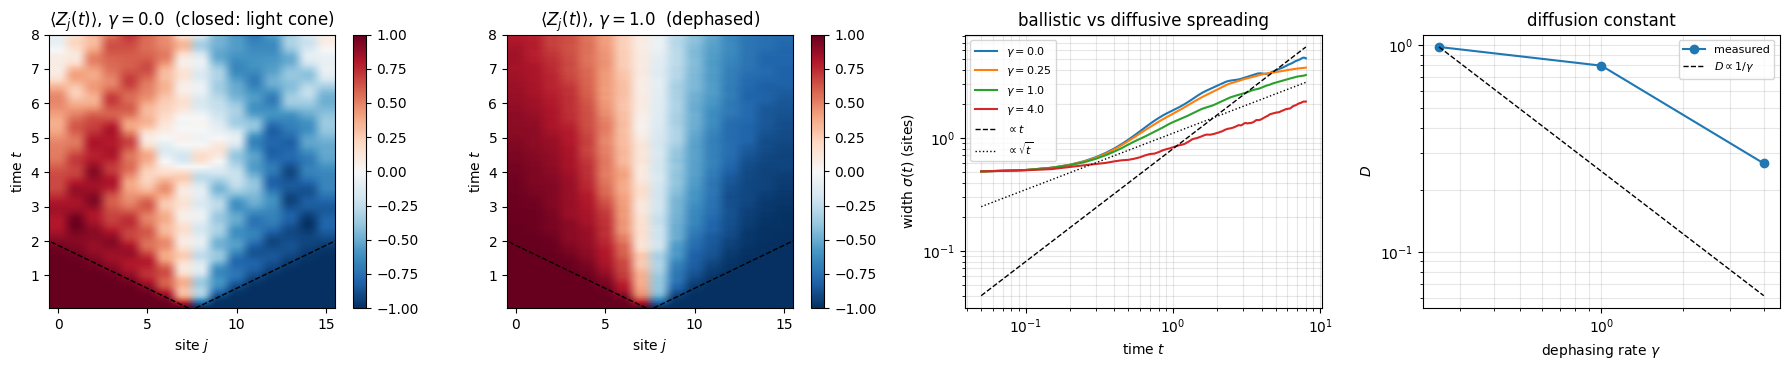

In [20]:
# ------------------------------------------------------------------------------
# FIGURE: the light cone, its destruction, and the crossover to diffusion
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, g_ in zip(axes[:2], (0.0, 1.0)):
    im = ax.imshow(prof_D[g_], origin="lower", aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
                   extent=[-0.5, N_D - 0.5, t_D[0], t_D[-1]])
    ax.plot(x0_D + 4 * t_D, t_D, "k--", lw=1); ax.plot(x0_D - 4 * t_D, t_D, "k--", lw=1)
    ax.set_xlim(-0.5, N_D - 0.5); ax.set_xlabel("site $j$"); ax.set_ylabel("time $t$")
    ax.set_title(rf"$\langle Z_j(t)\rangle$, $\gamma={g_}$" + ("  (closed: light cone)" if g_ == 0 else "  (dephased)"))
    plt.colorbar(im, ax=ax)
ax = axes[2]
for g_ in GAMMAS_D:
    ax.loglog(t_D, sig_D[g_], label=rf"$\gamma={g_}$")
ax.loglog(t_D, 0.8 * t_D, "k--", lw=1, label=r"$\propto t$")
ax.loglog(t_D, 1.1 * np.sqrt(t_D), "k:", lw=1, label=r"$\propto\sqrt{t}$")
ax.set_xlabel("time $t$"); ax.set_ylabel(r"width $\sigma(t)$ (sites)"); ax.set_title("ballistic vs diffusive spreading")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
ax = axes[3]
ax.loglog(gs, Ds, "o-", label="measured")
ax.loglog(gs, Ds[0] * (gs / gs[0]) ** -1.0, "k--", lw=1, label=r"$D\propto1/\gamma$")
ax.set_xlabel(r"dephasing rate $\gamma$"); ax.set_ylabel("$D$"); ax.set_title("diffusion constant")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.**

- *Left*: the closed chain reproduces the light cone of notebook 18 - a sharp front travelling at $4J$, with the
  region outside it untouched.
- *Centre left*: with dephasing the cone is gone. The profile spreads smoothly and much more slowly, and the edges
  are no longer sharp: the quasi-particles no longer propagate, they random-walk.
- *Centre right*: the widths on a log-log scale separate cleanly into slope $1$ (closed) and slope $1/2$ (dephased).
  The fitted exponents are printed above; the ballistic one is fitted only up to $t=1.5$, because at $t=2$ the front
  reaches the end of a 16-site chain and the width saturates for a reason that has nothing to do with physics.
- *Right*: the diffusion constant falls with $\gamma$, close to the $1/\gamma$ of the estimate. **Watching harder
  makes the system slower**: each measurement resets the phase, and the distance travelled coherently between
  measurements shrinks.

> **Physics insight.** The Hamiltonian was not changed. The chain became diffusive purely because information about
> where the spins point leaked into an environment. An open system is not a closed system with extra terms - and
> this is why real conductors, always watched by their phonons, show diffusive conduction where an idealised chain
> would be ballistic.

## 10. Summary: key takeaways

* The Lindblad equation can be **unravelled**: pure states evolve under the non-Hermitian $H_{\rm eff}=H-\tfrac i2\sum_j\gamma_jL_j^\dagger L_j$ and
  suffer random quantum jumps $|\psi\rangle\to L_j|\psi\rangle$ with rates $\gamma_j\langle L_j^\dagger L_j\rangle$. The loss of norm under $H_{\rm eff}$ *is* the jump probability.
* The probabilities cancel the normalisation factors, so the average $\overline{|\psi\rangle\langle\psi|}$ obeys the *linear* master equation although every
  trajectory is nonlinear. In Kraus language the MCWF step is the stochastic unravelling of the short-time channel; unravelling the Trotter–Kraus step
  factor by factor gives the engine's `lindblad_trotter_step_mcwf`, whose average equals the density-tensor step exactly.
* "No click" is information: the no-jump evolution drifts the state (an atom in a superposition relaxes to $|0\rangle$ in half of the runs without ever emitting).
  Dropping the non-Hermitian term gives wrong averages.
* Implementation: write one trajectory as a `lax.scan` over per-step keys, `vmap` it over per-trajectory keys, `jit` the whole thing; branch with
  `categorical` + `lax.switch`, never with Python `if`.
* Two errors: systematic $O(dt)$ and statistical $s/\sqrt M$, with $s\le1$ independent of $N$ for *bounded* observables but $s\sim\sqrt N$ for
  *extensive* ones. The trajectory mean is unbiased for quantities linear in $\rho$ only. Validate with pulls; check that the error bars cover the reference at the stated rate;
  remember that a pull test cannot see a bias smaller than its own error bar.
* Choose $dt$ from $\sum_j\delta p_j=dt\sum_j\gamma_j\langle L_j^\dagger L_j\rangle\lesssim0.1$ — an extensive condition, so $dt\propto1/N$ at fixed
  $\gamma$ — unless the stepper decides each channel independently, as the Trotter one does. The fixed-grid schemes approximate the
  waiting-time algorithm, which draws the jump time exactly from the decaying norm.
* Cost: $M\cdot2^N$ versus $4^N$; break-even $M\sim2^N$. Density tensors win for $N\lesssim10$; trajectories are the only option beyond $N\approx14$ — we ran $N=16$
  and verified it against an exact law.
* A trajectory is the state conditioned on one *measurement record* of the environment — photon counting here, homodyne detection or quantum
  state diffusion for other choices, all with the same $\rho(t)$. Trajectories therefore carry more than $\rho$: staircases, click records,
  entanglement of the monitored state. Nonlinear trajectory averages depend on the unravelling; the averaged entanglement entropy is an upper
  bound on the entanglement of formation of $\rho$, not an estimate of it.

## 11. Exercises

1. ★ **Dephasing trajectories.** For one qubit with $L=Z$, $H=0$, start from $|+\rangle$. What does a single trajectory of $\langle X\rangle$ look like? Show
   analytically that the ensemble average is $e^{-2\gamma t}$ (hint: the number of jumps is Poisson distributed) and verify with `qubit_trajectories`-like code.
2. ★ **The pitfall, demonstrated.** Modify `apply_neg_i_heff` so that it omits the $-\tfrac12\gamma L^\dagger L$ term (keep the jumps, with probabilities
   $\gamma\,dt\langle L^\dagger L\rangle$). Repeat experiment B and confirm that the ensemble now decays as $\tfrac12e^{-\gamma t/2}$ instead of
   $\tfrac12e^{-\gamma t}$ — the right steady state, reached at half the correct rate. Explain why $\langle X\rangle$ comes out right anyway.
3. ★★ **Systematic error.** For the $N=4$ checkpoint of Section 4.2 measure the deviation of both steppers from the density-tensor RK4 reference as a function of
   $dt\in\{0.2,0.1,0.05\}$ with $M$ large enough to resolve it. Confirm the first-order scaling. Which stepper has the smaller error constant?
4. ★★ **Extend the code: chunked accumulation.** Write `run_chunked(step, psi0, key, n_steps, observe, M, chunk)` that processes `M` trajectories in chunks
   and returns mean and standard error without ever storing more than `chunk` trajectories. Use it to push Section 8.3 to $N=18$.
5. ★★ **Physics: waiting-time distribution of a driven atom.** From `jumps_C` (experiment C) histogram the delays between successive clicks. Why does the
   distribution vanish at zero delay (**photon antibunching**)? Compare with $w(\tau)=\gamma\,|\langle1|e^{-iH_{\rm eff}\tau}|0\rangle|^2$.
6. ★★ **Entanglement depends on the unravelling.** Pair the sites up, $(0,1),(2,3),\dots$, and in Section 7 replace the two jump operators
   $\sigma^+_i,\sigma^+_{i+1}$ of each pair by the unitarily mixed pair $(\sigma^+_i\pm\sigma^+_{i+1})/\sqrt2$ with the same rate $\gamma$. Show
   algebraically that the dissipator is unchanged, check it with the density tensor for $N=4$, and compare the mean trajectory entanglement
   entropy. Physically: the detector can no longer tell which of the two sites emitted.
7. ★★★ **The waiting-time (integral) algorithm of Section 2.7.** Instead of deciding at every step, draw $r\in(0,1)$ once, propagate the
   *unnormalised* state under $H_{\rm eff}$ until $\langle\tilde\psi|\tilde\psi\rangle=r$, then jump. Implement it with `lax.scan` (carry: state,
   current $r$, key) and compare accuracy at large $dt$ ($dt=0.2$, say) with stepper A. Then argue about what is and is not gained: the no-jump
   probability is now *integrated* instead of Bernoulli-sampled, so several jumps in one step are no longer missed; but on a fixed grid the
   crossing is still located only to within $dt$, so an $O(dt)$ error in the jump time remains. Which of the two effects dominates here?
8. ★★★ **Dissipative state preparation.** With jump operators $L_i=\tfrac12(X_i+iY_i)\equiv\sigma^+_i$ and $H=0$ every initial state is pumped into $|0\dots0\rangle$. Design
   two-site jump operators that pump *any* state into a Bell pair, and verify with trajectories that the fidelity approaches one.

## 12. References

* J. Dalibard, Y. Castin, K. Mølmer, *Wave-function approach to dissipative processes in quantum optics*, Phys. Rev. Lett. **68**, 580 (1992).
* K. Mølmer, Y. Castin, J. Dalibard, *Monte Carlo wave-function method in quantum optics*, J. Opt. Soc. Am. B **10**, 524 (1993) — the detailed account of the algorithm used here.
* R. Dum, P. Zoller, H. Ritsch, *Monte Carlo simulation of the atomic master equation for spontaneous emission*, Phys. Rev. A **45**, 4879 (1992).
* H. J. Carmichael, *An Open Systems Approach to Quantum Optics*, Lecture Notes in Physics m18, Springer (1993) — "quantum trajectories".
* M. B. Plenio, P. L. Knight, *The quantum-jump approach to dissipative dynamics in quantum optics*, Rev. Mod. Phys. **70**, 101 (1998).
* A. J. Daley, *Quantum trajectories and open many-body quantum systems*, Adv. Phys. **63**, 77 (2014) — many-body applications, higher-order schemes.
* N. Gisin, I. C. Percival, *The quantum-state diffusion model applied to open systems*, J. Phys. A **25**, 5677 (1992) — the diffusive
  unravelling (continuous noise instead of jumps), a different stochastic process with the same $\rho(t)$.
* H. Nha, H. J. Carmichael, *Entanglement within the quantum trajectory description of open quantum systems*, Phys. Rev. Lett. **93**, 120408 (2004)
  — trajectory entanglement depends on the unravelling.
* C. H. Bennett, D. P. DiVincenzo, J. A. Smolin, W. K. Wootters, *Mixed-state entanglement and quantum error correction*,
  Phys. Rev. A **54**, 3824 (1996) — entanglement of formation as the minimum over pure-state decompositions, hence the bound of Section 7.
* Y. Li, X. Chen, M. P. A. Fisher, *Quantum Zeno effect and the many-body entanglement transition*, Phys. Rev. B **98**, 205136 (2018);
  B. Skinner, J. Ruhman, A. Nahum, *Measurement-induced phase transitions in the dynamics of entanglement*, Phys. Rev. X **9**, 031009 (2019).
* D. Gobert, C. Kollath, U. Schollwöck, G. Schütz, *Real-time dynamics in spin-1/2 chains with adaptive time-dependent density matrix
  renormalization group*, Phys. Rev. E **71**, 036102 (2005) — ballistic melting of a domain wall in the XXZ chain for $\Delta<1$.
* M. Žnidarič, *Dephasing-induced diffusive transport in the anisotropic Heisenberg model*, New J. Phys. **12**, 043001 (2010)
  — dephasing turns ballistic spin transport into diffusion (Section 9).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling, B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed.,
  Cambridge University Press (2007) — Chapter 7: random-number generation and the $1/\sqrt M$ error of Monte-Carlo estimators.
* W. Nagourney, J. Sandberg, H. Dehmelt, *Shelved optical electron amplifier: observation of quantum jumps*, Phys. Rev. Lett. **56**, 2797 (1986).
* Th. Sauter, W. Neuhauser, R. Blatt, P. E. Toschek, *Observation of quantum jumps*, Phys. Rev. Lett. **57**, 1696 (1986).
* J. C. Bergquist, R. G. Hulet, W. M. Itano, D. J. Wineland, *Observation of quantum jumps in a single atom*, Phys. Rev. Lett. **57**, 1699 (1986).
* Z. K. Minev *et al.*, *To catch and reverse a quantum jump mid-flight*, Nature **570**, 200 (2019).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/